# 01 EDA

**Objetivo:** Foco en análisis exploratorio, carga de data/raw, limpieza usando src.preprocessing y guardado del set final en data/processed.

In [198]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor


sys.path.append(os.path.abspath('..'))


# Definición de rutas base a los archivos de datos 
RAW_DATA_PATH_1 = '../data/raw/BD_IPSA_1940.xlsx'
RAW_DATA_PATH_2 = '../data/raw/HISTORICO_SUERTES.xlsx'
PROCESSED_DATA_PATH = '../data/processed/datos_limpios_modelo.csv'


Se realizó un análisis exploratorio inicial de ambas bases de datos con el fin de comprender su estructura general y obtener un contexto previo sobre la información disponible. En esta etapa se revisó la dimensión de cada conjunto de datos, la cantidad de registros y variables, los tipos de datos presentes en cada columna, la existencia de valores nulos y una vista preliminar de los primeros registros. Este proceso permitió identificar las características de las variables utilizadas, evaluar la calidad de los datos y establecer una base sólida para las etapas posteriores de preprocesamiento, selección de variables y modelado

In [199]:
# Cargar datos
df_reg = pd.read_excel('../data/raw/HISTORICO_SUERTES.xlsx')
df_clf = pd.read_excel('../data/raw/BD_IPSA_1940.xlsx')

# Vista general
print("REGRESIÓN")
print(df_reg.shape)
print(df_reg.info())
print(df_reg.head())

print("\nCLASIFICACIÓN")
print(df_clf.shape)
print(df_clf.info())
print(df_clf.head())

REGRESIÓN
(21027, 85)
<class 'pandas.DataFrame'>
RangeIndex: 21027 entries, 0 to 21026
Data columns (total 85 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   Período                    21027 non-null  int64         
 1   Hacienda                   21027 non-null  int64         
 2   Nombre                     21027 non-null  str           
 3   Zona                       21027 non-null  str           
 4   Tenencia                   21026 non-null  float64       
 5   Suerte                     21027 non-null  str           
 6   Suelo                      17269 non-null  str           
 7   Area Neta                  21027 non-null  float64       
 8   Dist Km                    21022 non-null  float64       
 9   Variedad                   21027 non-null  str           
 10  Cod.Estado #               21027 non-null  int64         
 11  Cod.Estado                 21027 non-null  str          

A partir del análisis exploratorio realizado previamente, se identificó que el dataset de regresión contenía columnas completamente vacías, específicamente Fert.Nitrogen y Sum Oscilación Temp Ciclo. Dado que estas variables no contienen información (todos sus valores son nulos), se determinó que no aportan valor al modelo, por lo que fueron eliminadas del conjunto de datos.

Adicionalmente, en el dataset de clasificación se encontró la columna “Unnamed: 0”, la cual corresponde a un índice generado. Esta variable no tiene significado predictivo ni aporta información relevante para el análisis, por lo que también fue eliminada.

In [200]:
# Eliminar columnas totalmente vacías
df_reg = df_reg.dropna(axis=1, how='all')
df_clf = df_clf.dropna(axis=1, how='all')

# Eliminar columnas irrelevantes tipo índice
df_clf = df_clf.drop(columns=['Unnamed: 0'], errors='ignore')
df_reg = df_reg.drop(columns=['Unnamed: 0'], errors='ignore')

print("Columnas finales en regresión:", df_reg.shape[1])
print("Columnas finales en clasificación:", df_clf.shape[1])

Columnas finales en regresión: 83
Columnas finales en clasificación: 20


Una vez realizada una limpieza básica de los valores nulos, se procede a un análisis más detallado de la calidad de los datos. En esta etapa, se identifican las variables con una alta proporción de valores faltantes y aquellas con una cantidad manejable de datos nulos, con el objetivo de definir un tratamiento adecuado para cada caso

In [201]:
#Mostrar todas las variables 
pd.set_option('display.max_rows', None)

#Organizamos los valores nulos de forma descendente 
missing_reg = df_reg.isnull().mean().sort_values(ascending=False) * 100
missing_clf = df_clf.isnull().mean().sort_values(ascending=False) * 100

print("Porcentaje de valores faltantes - Regresión")
print(missing_reg)

print("\nPorcentaje de valores faltantes - Clasificación")
print(missing_clf)

Porcentaje de valores faltantes - Regresión
Urea 46%                   96.561564
NITRAX-S                   96.442669
MEZ                        95.382128
MicroZinc                  94.535597
Boro Granul.               93.888810
Sul.Amonio                 93.546393
NITO_XTEND                 82.503448
Vinaza                     80.510772
Temp. Media Ciclo          78.456271
Temp. Media 0-3            78.456271
Precipitacion 0_3          78.456271
Oscilacion Temp Med 0-3    78.456271
Humedad Rel Media Ciclo    78.456271
Temp Min Ciclo             78.456271
Humedad Rel Media 0-3      78.456271
Temp Max Ciclo             78.456271
Precipitacion Ciclo        78.456271
Radicion Solar 0-3         78.456271
Radiacion Solar Ciclo      78.456271
Oscilacion Temp Ciclo      78.456271
Evaporacion 0-3            78.456271
Evaporacion Ciclo          78.456271
%Infest.Diatrea            73.367575
Codigo Estacion            70.109859
D.S.                       65.910496
Num.Riegos                 59.8

Con el fin de obtener una visión más clara de la presencia de valores nulos, se generará un gráfico de barras que permita visualizar de manera más sencilla la cantidad de datos faltantes por variable. Esta representación facilita la interpretación y el análisis de la calidad de los datos.

Este procedimiento se realizará únicamente sobre el dataset de regresión, ya que en el análisis previo se evidenció que las variables del dataset de clasificación se encuentran completas y no presentan valores nulos. Por esta razón, el análisis gráfico de datos faltantes se enfocará exclusivamente en las variables asociadas al problema de regresión.

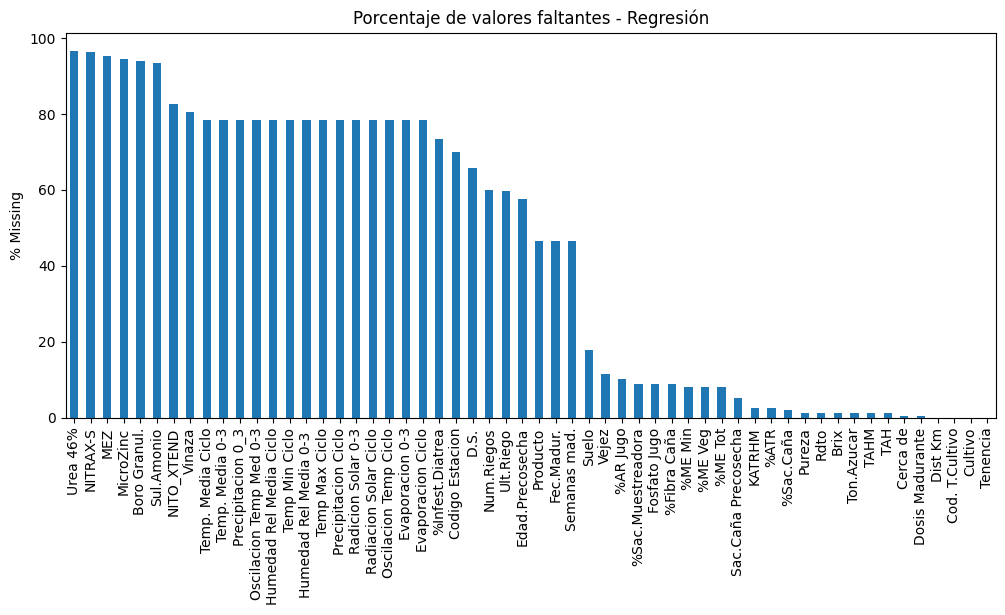

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

In [202]:
# Solo mostramos columnas con missing > 0 para no generar gráficas vacías
missing_reg_plot = missing_reg[missing_reg > 0]

plt.figure(figsize=(12, 5))
missing_reg_plot.plot(kind='bar')
plt.title('Porcentaje de valores faltantes - Regresión')
plt.ylabel('% Missing')
plt.show()

plt.figure(figsize=(12, 5))


# Analisis Detallado de la Base de Datos Historico de Suertes

A partir de la gráfica, se identificó con mayor claridad que varias variables del dataset de regresión presentan porcentajes de valores nulos entre el 80% y el 97%. Debido a este alto nivel de datos faltantes, se decidió descartar dichas variables, ya que la cantidad de información disponible es demasiado limitada para realizar una imputación confiable. En estos casos, aplicar medidas como la mediana podría no ser lo más adecuado, pues los pocos valores existentes podrían no representar de forma correcta el comportamiento real de la variable.

Además, se observó que gran parte de las columnas eliminadas corresponden a variables relacionadas con fertilizantes. Desde el contexto del negocio y del cultivo de caña de azúcar, estas variables podrían ser potencialmente importantes para explicar el rendimiento del cultivo. Sin embargo, desde el punto de vista estadístico, la gran cantidad de valores faltantes representa una limitación significativa, ya que impide extraer conclusiones confiables y podría introducir sesgos en el análisis. Por esta razón, como equipo se decidió eliminarlas, priorizando la calidad y consistencia de los datos disponibles.

Por otra parte, se observó que existen variables con porcentajes de valores nulos en un rango intermedio, aproximadamente entre el 50% y el 80%. Estas variables no serán descartadas de manera inmediata, sino que serán analizadas posteriormente con mayor detalle para determinar si resulta más conveniente eliminarlas o aplicar algún método de imputación, considerando tanto el comportamiento estadístico de los datos como su relevancia dentro del contexto del cultivo de caña de azúcar.

En cuanto al dataset de clasificación, no se evidencian problemas de valores nulos, ya que todas sus variables presentan un porcentaje de datos faltantes del 0%. Por ello, en este caso la limpieza y selección de variables no se basará en la ausencia de datos, sino principalmente en su relevancia dentro del contexto del problema y su posible aporte al modelo de clasificación.

In [203]:
#Eliminamos las variable con porcentaje de nullos mayor al 80%
cols_mayor_80 = missing_reg[missing_reg > 80].index
df_reg = df_reg.drop(columns=cols_mayor_80)

print("Columnas eliminadas:")
print(list(cols_mayor_80))
print("Nuevo número de columnas:", df_reg.shape[1])

Columnas eliminadas:
['Urea 46%', 'NITRAX-S', 'MEZ', 'MicroZinc', 'Boro Granul.', 'Sul.Amonio', 'NITO_XTEND', 'Vinaza']
Nuevo número de columnas: 75


Adicionalmente, dentro del dataset se identificó la presencia de variables que corresponden más a resultados obtenidos después de la extracción o procesamiento de la caña que a factores propios del proceso productivo en campo. Entre estas se encuentran variables como TCHM, RDTO, TAH, pureza, % fibra, entre otras.

Aunque estas variables pueden estar relacionadas con el rendimiento final, no representan condiciones iniciales ni factores explicativos directos del cultivo, sino más bien indicadores de resultado o variables derivadas de etapas posteriores al proceso de producción de la caña.

Debido a esto, para el dataset de regresión se decidió eliminarlas, ya que su inclusión podría generar sesgos en el análisis y afectar la correcta interpretación del modelo, al incorporar información que no corresponde a variables predictoras del proceso, sino a resultados asociados a la cosecha o al procesamiento posterior.

In [204]:
#Lista de variables a eliminar
cols_resultado = [
    'TCHM',
    'Ton.Azucar',
    'Rdto',
    'TAH',
    'TAHM',
    '%Sac.Muestreadora',
    '%ATR',
    'KATRHM',
    'Pureza',
    'Brix',
    '%Fibra Caña',
    '%AR Jugo',
    '%ME Min',
    '%ME Veg',
    '%ME Tot',
    'Sac.Caña Precosecha',
    'Fosfato Jugo',
    'Edad.Precosecha',
    'TonUltCorte'
]


cols_presentes = [col for col in cols_resultado if col in df_reg.columns]

df_reg = df_reg.drop(columns=cols_presentes, errors='ignore')

print("Se eliminaron estas columnas:")
print(cols_presentes)
print("Total eliminadas:", len(cols_presentes))
print("Nuevo shape:", df_reg.shape)
print(df_reg.info())

Se eliminaron estas columnas:
['TCHM', 'Ton.Azucar', 'Rdto', 'TAH', 'TAHM', '%Sac.Muestreadora', '%ATR', 'KATRHM', 'Pureza', 'Brix', '%Fibra Caña', '%AR Jugo', '%ME Min', '%ME Veg', '%ME Tot', 'Sac.Caña Precosecha', 'Fosfato Jugo', 'Edad.Precosecha', 'TonUltCorte']
Total eliminadas: 19
Nuevo shape: (21027, 56)
<class 'pandas.DataFrame'>
RangeIndex: 21027 entries, 0 to 21026
Data columns (total 56 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Período                  21027 non-null  int64         
 1   Hacienda                 21027 non-null  int64         
 2   Nombre                   21027 non-null  str           
 3   Zona                     21027 non-null  str           
 4   Tenencia                 21026 non-null  float64       
 5   Suerte                   21027 non-null  str           
 6   Suelo                    17269 non-null  str           
 7   Area Neta                21027 non-n

Después de eliminar en el dataset de regresión las variables que representaban resultados y no factores predictivos, se continuará con la depuración de la base de datos historico de suertes eliminando variables identificadoras o de referencia. Estas columnas, como códigos, índices o identificadores de la caña, no aportan información relevante para el análisis, por lo que se excluirán para conservar únicamente variables útiles en la construcción de los modelos.

In [205]:
#Identificadores del dataset de regresion:
cols_identificadores = [
    'Hacienda',
    'Nombre',
    'Suerte',
    'Cod.Estado #',
    'Cod.Estado',
    'Cod. T.Cultivo',
    'Codigo Estacion',
    'Período'

]

df_reg = df_reg.drop(columns=cols_identificadores, errors='ignore')

print("Columnas identificadoras eliminadas:")
print(cols_identificadores)
print("Nuevo número de columnas en regresión:", df_reg.shape[1])
print(df_reg.info())


Columnas identificadoras eliminadas:
['Hacienda', 'Nombre', 'Suerte', 'Cod.Estado #', 'Cod.Estado', 'Cod. T.Cultivo', 'Codigo Estacion', 'Período']
Nuevo número de columnas en regresión: 48
<class 'pandas.DataFrame'>
RangeIndex: 21027 entries, 0 to 21026
Data columns (total 48 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Zona                     21027 non-null  str           
 1   Tenencia                 21026 non-null  float64       
 2   Suelo                    17269 non-null  str           
 3   Area Neta                21027 non-null  float64       
 4   Dist Km                  21022 non-null  float64       
 5   Variedad                 21027 non-null  str           
 6   F.Siembra                21027 non-null  datetime64[us]
 7   D.S.                     7168 non-null   str           
 8   Ult.Riego                8470 non-null   datetime64[us]
 9   Edad Ult Cos             21027 non-n

Una vez eliminadas las variables totalmente vacías o con muchos valores nulos, los identificadores y aquellas que correspondían a resultados o mediciones posteriores al proceso productivo, se volvió a calcular y graficar el porcentaje de valores faltantes. Esta segunda revisión permitió centrarse únicamente en las variables realmente candidatas para el modelado.

Con apoyo de la gráfica de missing values y del contexto del negocio, se analizaron las variables que aún conservaban porcentajes altos de valores nulos, especialmente las relacionadas con condiciones climáticas y de manejo agronómico. A partir de ello, se definió cuáles variables podían conservarse, cuáles requerían estrategias de imputación y cuáles debían descartarse por el alto nivel de incertidumbre que introducirían en el modelo.

In [206]:
#Mostramos todas las variables 
pd.set_option('display.max_rows', None)

#Organizamos los valores nulos de forma descendente 
missing_reg = df_reg.isnull().mean().sort_values(ascending=False) * 100


print("Porcentaje de valores faltantes - Regresión")
print(missing_reg)


Porcentaje de valores faltantes - Regresión
Precipitacion 0_3          78.456271
Precipitacion Ciclo        78.456271
Temp. Media Ciclo          78.456271
Temp. Media 0-3            78.456271
Humedad Rel Media 0-3      78.456271
Humedad Rel Media Ciclo    78.456271
Temp Min Ciclo             78.456271
Temp Max Ciclo             78.456271
Evaporacion 0-3            78.456271
Evaporacion Ciclo          78.456271
Radicion Solar 0-3         78.456271
Radiacion Solar Ciclo      78.456271
Oscilacion Temp Ciclo      78.456271
Oscilacion Temp Med 0-3    78.456271
%Infest.Diatrea            73.367575
D.S.                       65.910496
Num.Riegos                 59.870643
Ult.Riego                  59.718457
Producto                   46.502116
Semanas mad.               46.487849
Fec.Madur.                 46.487849
Suelo                      17.872259
Vejez                      11.627907
%Sac.Caña                   2.135350
Cerca de                    0.599230
Dosis Madurante             0.4

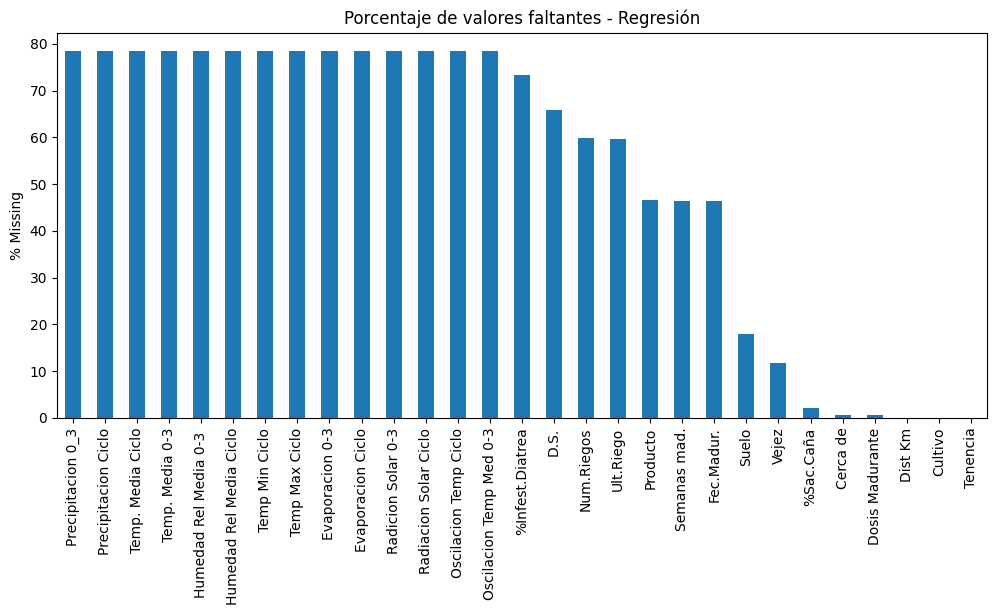

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

In [207]:
missing_reg_plot = missing_reg[missing_reg > 0]

plt.figure(figsize=(12, 5))
missing_reg_plot.plot(kind='bar')
plt.title('Porcentaje de valores faltantes - Regresión')
plt.ylabel('% Missing')
plt.show()

plt.figure(figsize=(12, 5))


Se eliminaron las variables climáticas relacionadas con temperatura, humedad, radiación, evaporación y precipitación, ya que presentaban alrededor de 78% de valores faltantes. Aunque estas variables pueden influir en el rendimiento y la calidad de la caña, imputar una cantidad tan alta de datos habría sido poco confiable.

Esto se debe a que las variables climáticas no son estables ni uniformes, sino que cambian según la zona y el momento del ciclo del cultivo. Por ello, completar artificialmente la mayor parte de sus valores podría generar sesgos en el modelo y alejar el análisis de las condiciones reales del cultivo.


In [208]:
cols_descartar_final = missing_reg[missing_reg > 75].index

df_reg = df_reg.drop(columns=cols_descartar_final, errors='ignore')

print("Columnas eliminadas por tener más de 75% de valores faltantes:")
print(list(cols_descartar_final))
print("Nuevo número de columnas:", df_reg.shape[1])
print(df_reg.info())


Columnas eliminadas por tener más de 75% de valores faltantes:
['Precipitacion 0_3', 'Precipitacion Ciclo', 'Temp. Media Ciclo', 'Temp. Media 0-3', 'Humedad Rel Media 0-3 ', 'Humedad Rel Media Ciclo', 'Temp Min Ciclo', 'Temp Max Ciclo', 'Evaporacion 0-3', 'Evaporacion Ciclo', 'Radicion Solar 0-3', 'Radiacion Solar Ciclo', 'Oscilacion Temp Ciclo', 'Oscilacion Temp Med 0-3']
Nuevo número de columnas: 34
<class 'pandas.DataFrame'>
RangeIndex: 21027 entries, 0 to 21026
Data columns (total 34 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Zona                    21027 non-null  str           
 1   Tenencia                21026 non-null  float64       
 2   Suelo                   17269 non-null  str           
 3   Area Neta               21027 non-null  float64       
 4   Dist Km                 21022 non-null  float64       
 5   Variedad                21027 non-null  str           
 6   F.Siembra   

Durante la depuración del dataset de regresión se eliminaron inicialmente las variables D.S., Producto y Cosechó, ya que no aportaban un valor predictivo claro al modelo. En el caso de D.S., no se contaba con suficiente claridad sobre su significado y además presentaba una alta proporción de datos faltantes. La variable Producto mostraba categorías inconsistentes y redundancia parcial con otras variables de maduración más estructuradas, mientras que Cosechó correspondía principalmente a códigos internos de operación, sin una relación agronómica directa con las variables objetivo.

Asimismo, se excluyeron Num.Riegos y Ult.Riego debido a su alto porcentaje de valores faltantes y a la dificultad de imputarlas de forma confiable. En particular, Ult.Riego, al ser una fecha, no podía completarse de manera metodológicamente adecuada, y en Num.Riegos asumir valores de cero habría sido una imputación poco sustentada. En contraste, se conservaron M3 Riego y DDUlt.Riego, ya que ambas presentaban información completa y representaban de manera más útil el manejo hídrico del cultivo.

También se compararon Fec.Madur. y Semanas mad., observándose que ambas compartían exactamente el mismo patrón de valores faltantes: cuando una tenía dato, la otra también, y cuando una estaba ausente, la otra igualmente. Esto indicó que ambas provenían del mismo proceso de registro asociado a la maduración del cultivo. Por esta razón, se decidió conservar Semanas mad., por ser una variable más directa e interpretable, y eliminar Fec.Madur., ya que correspondía a una fecha cruda que requería transformaciones adicionales.

Finalmente, se descartaron las variables Zona, Cerca de, Tenencia y Suelo. Aunque estas variables podían estar asociadas indirectamente a diferencias productivas entre lotes, no se contaba con información complementaria suficiente para interpretar de manera adecuada las condiciones específicas representadas por sus categorías. En el caso particular de Suelo, además, se consideró que el análisis se encuentra centrado en cultivos ubicados en el Valle del Cauca, una región relativamente homogénea dentro del contexto cañero colombiano, lo que reduce parcialmente la variabilidad esperada en este tipo de condición. En consecuencia, su inclusión habría dificultado la explicación del modelo y la interpretación agronómica de los resultados, por lo que se priorizaron variables con una relación más directa y mejor sustentada con el proceso productivo de la caña de azúcar.

De igual forma, se eliminaron las variables F.Siembra y F.Ult.Corte. Aunque ambas contenían información temporal del cultivo, se consideró que su aporte quedaba en buena medida resumido en la variable Edad Ult Cos, la cual resulta más directa e interpretable para el análisis. Además, al tratarse de fechas crudas, su inclusión requería transformaciones adicionales que no aportaban ventajas claras frente a una variable ya derivada y más fácilmente utilizable dentro del modelo.

In [209]:
cols_descartar = [
    'D.S.',
    'Producto',
    'Cosechó',
    'Num.Riegos',
    'Ult.Riego',
    'Fec.Madur.',
    'Cerca de',
    'Tenencia',
    'Zona',
    'Suelo',
    'F.Siembra',
    'F.Ult.Corte'
]

df_reg = df_reg.drop(columns=cols_descartar, errors='ignore')

print("Columnas eliminadas hasta ahora:")
print(cols_descartar)
print("Nuevo número de columnas:", df_reg.shape[1])

print(df_reg.info())

Columnas eliminadas hasta ahora:
['D.S.', 'Producto', 'Cosechó', 'Num.Riegos', 'Ult.Riego', 'Fec.Madur.', 'Cerca de', 'Tenencia', 'Zona', 'Suelo', 'F.Siembra', 'F.Ult.Corte']
Nuevo número de columnas: 22
<class 'pandas.DataFrame'>
RangeIndex: 21027 entries, 0 to 21026
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Area Neta               21027 non-null  float64
 1   Dist Km                 21022 non-null  float64
 2   Variedad                21027 non-null  str    
 3   Edad Ult Cos            21027 non-null  float64
 4   Destino 1=Semilla       21027 non-null  int64  
 5   Cultivo                 21025 non-null  str    
 6   Dosis Madurante         20923 non-null  float64
 7   Semanas mad.            11252 non-null  float64
 8   TCH                     21027 non-null  float64
 9   %Sac.Caña               20578 non-null  float64
 10  Vejez                   18582 non-null  float64
 11  Tipo

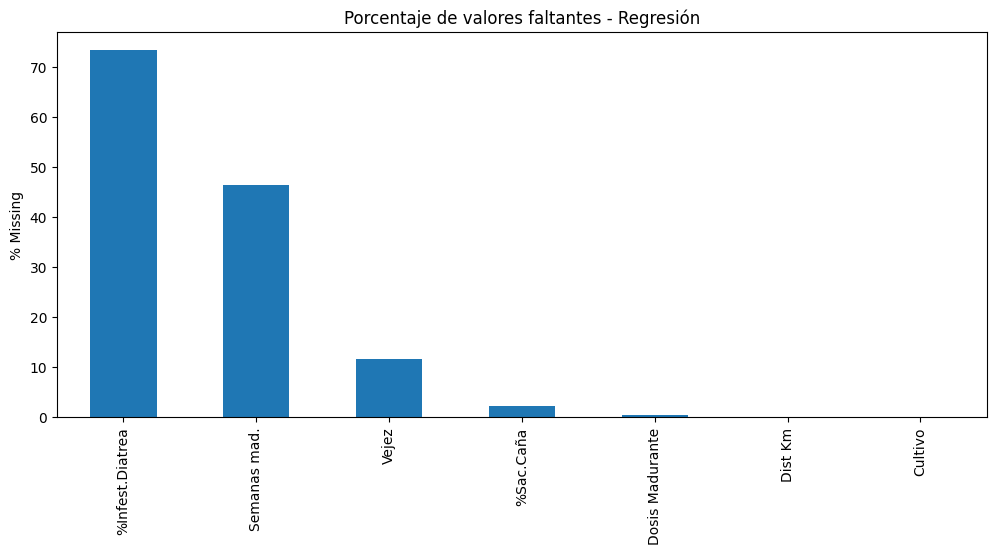

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

In [210]:
missing_reg = df_reg.isnull().mean().sort_values(ascending=False) * 100

missing_reg_plot = missing_reg[missing_reg > 0]

plt.figure(figsize=(12, 5))
missing_reg_plot.plot(kind='bar')
plt.title('Porcentaje de valores faltantes - Regresión')
plt.ylabel('% Missing')
plt.show()

plt.figure(figsize=(12, 5))

Sospechamos que la variable lluvia ciclo corresponde a la suma de las demás variables de lluvia. Por ello, vamos a verificar si esta hipótesis es correcta. En caso de confirmarla, optaremos por conservar únicamente las variables de lluvia por etapas, ya que estas podrían contener la misma información de forma más desagregada

In [211]:
#Copiamos dataset con las variables 
df_lluvia_check = df_reg[[
    'Lluvias Ciclo',
    'Lluvias 0 -3',
    'Lluvias tres a seis',
    'Lluvias seis a nueve',
    'Luvias 9 -FC'
]].copy()

#Realizamos la suma para comprobar sospechas
df_lluvia_check['suma_tramos'] = (
    df_lluvia_check['Lluvias 0 -3'] +
    df_lluvia_check['Lluvias tres a seis'] +
    df_lluvia_check['Lluvias seis a nueve'] +
    df_lluvia_check['Luvias 9 -FC']
)

#Revisamos
print(df_lluvia_check[['Lluvias Ciclo', 'suma_tramos']].head(20))
print(df_lluvia_check[['Lluvias Ciclo', 'suma_tramos']].corr())

    Lluvias Ciclo  suma_tramos
0          1038.0       1038.0
1             0.0          0.0
2          1002.0       1002.0
3             0.0          0.0
4           991.0        991.0
5           847.0        847.0
6          1261.0       1261.0
7          1002.0       1002.0
8             0.0          0.0
9             0.0          0.0
10          684.0        684.0
11         1269.0       1269.0
12            0.0          0.0
13            0.0          0.0
14            0.0          0.0
15            0.0          0.0
16          950.0        950.0
17          730.0        730.0
18         1038.0       1038.0
19          847.0        847.0
               Lluvias Ciclo  suma_tramos
Lluvias Ciclo       1.000000     0.999998
suma_tramos         0.999998     1.000000


Confirmamos nuestra teoría, por lo que procedemos a eliminar la variable lluvia ciclo, ya que representa la suma de las demás variables de lluvia.

In [212]:
cols_descartar = ['Lluvias Ciclo']

df_reg = df_reg.drop(columns=cols_descartar, errors='ignore')

print("Nuevo número de columnas:", df_reg.shape[1])

print(df_reg.info()) 

Nuevo número de columnas: 21
<class 'pandas.DataFrame'>
RangeIndex: 21027 entries, 0 to 21026
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Area Neta               21027 non-null  float64
 1   Dist Km                 21022 non-null  float64
 2   Variedad                21027 non-null  str    
 3   Edad Ult Cos            21027 non-null  float64
 4   Destino 1=Semilla       21027 non-null  int64  
 5   Cultivo                 21025 non-null  str    
 6   Dosis Madurante         20923 non-null  float64
 7   Semanas mad.            11252 non-null  float64
 8   TCH                     21027 non-null  float64
 9   %Sac.Caña               20578 non-null  float64
 10  Vejez                   18582 non-null  float64
 11  Tipo Quema              21027 non-null  str    
 12  T.Corte                 21027 non-null  str    
 13  M3 Riego                21027 non-null  float64
 14  DDUlt.Riego         

# Imputacion valores para el dataset de Regresion

Los valores nulos de las variables dosis de madurante y porcentaje de Diatraea serán imputados con 0, asumiendo que en esos cultivos no hubo presencia registrada de bacterias ni aplicación de madurante.”

In [213]:
from src.preprocessing import imputar_por_regla_negocio

# Aplicamos imputación por regla de negocio en este caso añadimos 0 para las variables 'Dosis Madurante' y '%Infest.Diatrea' ya que es lógico asumir que si no se registró
# una dosis madurante o una infestación de diatrea, el valor es 0 en lugar de nulo. No hay columnas que no apliquen en este caso.
df_reg = imputar_por_regla_negocio(
    df_reg,
    cols_cero=['Dosis Madurante', '%Infest.Diatrea'],
    cols_no_aplica=[]
)


print(df_reg[['Dosis Madurante', '%Infest.Diatrea']].isnull().sum())
print(df_reg[['Dosis Madurante', '%Infest.Diatrea']].head(20))


Dosis Madurante    0
%Infest.Diatrea    0
dtype: int64
    Dosis Madurante  %Infest.Diatrea
0               1.0           0.0000
1               0.0           0.0000
2               1.1           0.0000
3               0.0           0.0000
4               0.0           0.0000
5               1.0           1.8861
6               1.3           0.0000
7               1.1           0.0000
8               0.0           0.0000
9               0.0           0.0000
10              0.0           0.0000
11              0.0           8.9981
12              0.0           0.0000
13              0.0           0.0000
14              0.0           0.0000
15              0.0           0.0000
16              0.0           0.0000
17              1.2           0.0000
18              1.0           1.6393
19              1.0           1.4626


Para la variable Dist KM, se utilizará la mediana para imputar los valores nulos, ya que son aproximadamente cinco registros faltantes. En el caso de la variable cultivo, al ser una variable categórica con categorías como orgánico o normal, se imputará utilizando la moda

In [214]:
#Imputamos con la mediana por ser una variable numerica
df_reg['Dist Km'] = df_reg['Dist Km'].fillna(df_reg['Dist Km'].median())

#Imputamos con la moda por ser una variable categorica
df_reg['Cultivo'] = df_reg['Cultivo'].fillna(df_reg['Cultivo'].mode()[0])

print(df_reg[['Dist Km', 'Cultivo']].isnull().sum())

Dist Km    0
Cultivo    0
dtype: int64


En cuanto a la variable Vejez, se decidió revisar primero su distribución y dispersión con el fin de determinar cuál medida de tendencia central resultaba más adecuada para imputar sus valores faltantes. Es decir, antes de completar los datos ausentes, se evaluó si la media o la mediana representaban mejor el comportamiento real de la variable.

En el caso de Semanas mad., se observó que los valores nulos se presentaban principalmente cuando la Dosis Madurante era igual a cero, lo que sugiere que esta variable solo se registraba cuando efectivamente existía aplicación de madurante. Por esta razón, antes de imputarla directamente, se planteó un análisis comparativo para estudiar cómo se comporta Semanas mad. según distintos rangos de Dosis Madurante, con el objetivo de decidir si la imputación debía realizarse con una mediana global o de manera diferenciada por categorías de dosis.

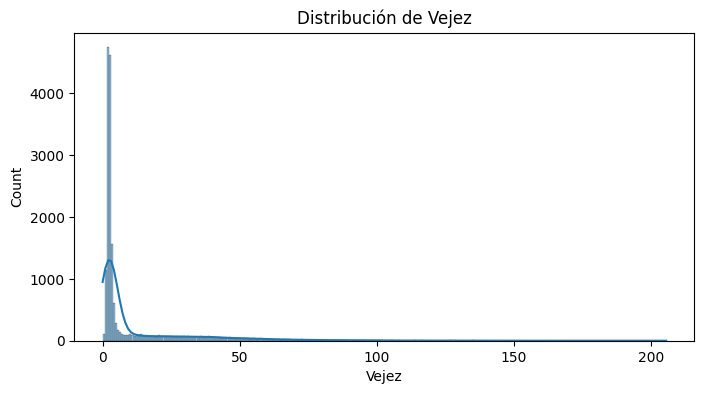

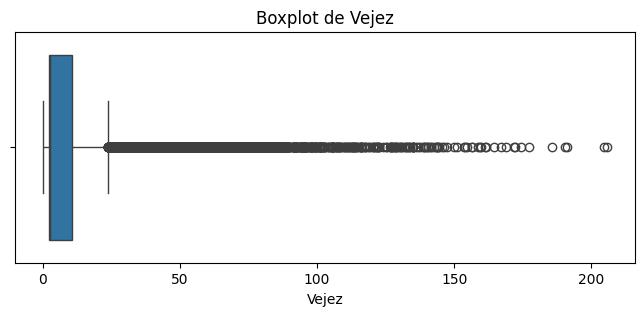

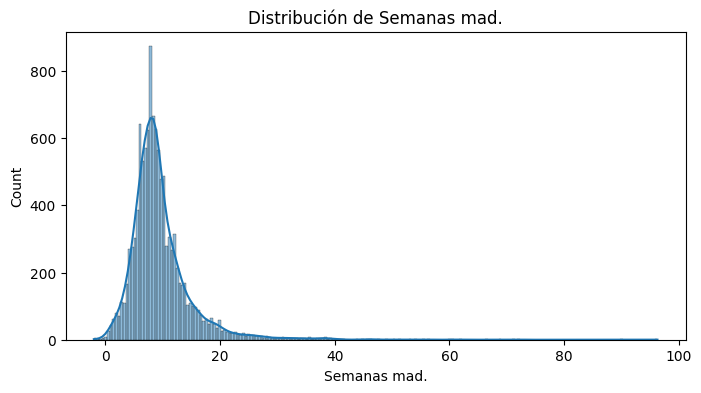

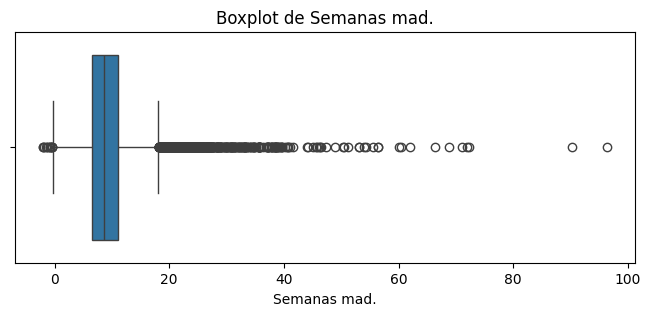

In [215]:
for col in ['Vejez', 'Semanas mad.']:
    plt.figure(figsize=(8,4))
    sns.histplot(df_reg[col].dropna(), kde=True)
    plt.title(f'Distribución de {col}')
    plt.show()

    plt.figure(figsize=(8,3))
    sns.boxplot(x=df_reg[col].dropna())
    plt.title(f'Boxplot de {col}')
    plt.show()

In [216]:
print("=== Vejez ===")
print(df_reg['Vejez'].describe())

print("\nMediana Vejez:")
print(df_reg['Vejez'].median())

print("\n=== Semanas mad. ===")
print(df_reg['Semanas mad.'].describe())

print("\nMediana Semanas mad.:")
print(df_reg['Semanas mad.'].median())

=== Vejez ===
count    18582.000000
mean        12.294125
std         20.993880
min          0.017000
25%          2.108000
50%          2.737000
75%         10.756750
max        205.650000
Name: Vejez, dtype: float64

Mediana Vejez:
2.737

=== Semanas mad. ===
count    11252.000000
mean         9.588708
std          5.585010
min         -2.000000
25%          6.571428
50%          8.571428
75%         11.142857
max         96.285714
Name: Semanas mad., dtype: float64

Mediana Semanas mad.:
8.571428


El análisis mostró que la variable Vejez presenta una distribución altamente asimétrica hacia la derecha, con una mediana de 2.737 frente a una media de 12.29, lo que evidencia la presencia de valores extremos elevados. Por ello, la mediana se consideró una medida más robusta y representativa que la media.

In [217]:
# Imputación de Vejez con mediana
mediana_vejez = df_reg['Vejez'].median()
df_reg['Vejez'] = df_reg['Vejez'].fillna(mediana_vejez)

print("Mediana usada para Vejez:", mediana_vejez)
print("Nulos restantes en Vejez:", df_reg['Vejez'].isnull().sum())

Mediana usada para Vejez: 2.737
Nulos restantes en Vejez: 0


El análisis por rangos de Dosis Madurante mostró que la variable Semanas mad. presenta medianas muy similares en los grupos con mayor cantidad de observaciones, especialmente entre los intervalos 0-1 y 1-2. Esto sugiere que su comportamiento no varía de manera marcada según la dosis aplicada. Por ello, una imputación por categorías no parece aportar una ventaja clara frente a una imputación más simple basada en la mediana. No obstante, antes de imputar, conviene depurar valores inconsistentes, como registros negativos, dado que no tienen interpretación agronómica válida.

In [218]:
df_sem = df_reg.copy()

df_sem['Rango_Dosis'] = pd.cut(
    df_sem['Dosis Madurante'],
    bins=[-0.1, 0, 1, 2, 5],
    labels=['0', '0-1', '1-2', '2-5']
)

# Resumen estadístico de Semanas mad. por rango de dosis
resumen_sem = df_sem.groupby('Rango_Dosis', observed=False)['Semanas mad.'].describe()
print(resumen_sem)

              count       mean       std       min       25%        50%  \
Rango_Dosis                                                               
0              14.0  10.908163  4.096025  3.857142  7.178571  11.642857   
0-1          6760.0   9.540891  5.440848 -2.000000  6.714285   8.571428   
1-2          4471.0   9.657475  5.803540 -1.285714  6.428571   8.428571   
2-5             7.0   9.204081  2.041836  7.142857  7.499999   8.285714   

                   75%        max  
Rango_Dosis                        
0            14.499999  15.714285  
0-1          11.000000  96.285714  
1-2          11.428571  71.857142  
2-5          11.071428  11.857142  


Realizamos la imputacion de los valores atipicos para vejez estos incluyen negativos y datos muy altos 

In [219]:
print("Negativos:", (df_reg['Semanas mad.'] < 0).sum())
print("Mayores a 60:", (df_reg['Semanas mad.'] > 60).sum())

# Reemplazamos valores sospechosos por NaN
df_reg.loc[
    (df_reg['Semanas mad.'] < 0) | (df_reg['Semanas mad.'] > 60),
    'Semanas mad.'
] = pd.NA

# Imputamos con mediana
mediana_sem = df_reg['Semanas mad.'].median()
df_reg['Semanas mad.'] = df_reg['Semanas mad.'].fillna(mediana_sem)

# Verificación
print("Mediana usada:", mediana_sem)
print("Nulos restantes en Semanas mad.:", df_reg['Semanas mad.'].isnull().sum())
print(df_reg['Semanas mad.'].describe())

Negativos: 13
Mayores a 60: 10
Mediana usada: 8.571428
Nulos restantes en Semanas mad.: 0
count    21027.000000
mean         9.091596
std          3.865516
min          0.000000
25%          8.285714
50%          8.571428
75%          8.714285
max         56.428571
Name: Semanas mad., dtype: float64


En el caso de %Sac.Caña, al tratarse de una variable objetivo del problema de regresión, no se consideró apropiado imputar sus valores faltantes. Dado que los registros ausentes representaban una proporción baja del total, se optó por excluir únicamente esas filas en el momento de construir el modelo correspondiente, evitando así introducir valores artificiales en la variable que se desea predecir.

In [220]:
df_reg_sacarosa = df_reg.dropna(subset=['%Sac.Caña']).copy()

print("Shape original:", df_reg.shape)
print("Shape sin nulos en %Sac.Caña:", df_reg_sacarosa.shape)
print("Registros eliminados:", df_reg.shape[0] - df_reg_sacarosa.shape[0])

print(df_reg_sacarosa.info()) 


Shape original: (21027, 21)
Shape sin nulos en %Sac.Caña: (20578, 21)
Registros eliminados: 449
<class 'pandas.DataFrame'>
Index: 20578 entries, 0 to 20974
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Area Neta               20578 non-null  float64
 1   Dist Km                 20578 non-null  float64
 2   Variedad                20578 non-null  str    
 3   Edad Ult Cos            20578 non-null  float64
 4   Destino 1=Semilla       20578 non-null  int64  
 5   Cultivo                 20578 non-null  str    
 6   Dosis Madurante         20578 non-null  float64
 7   Semanas mad.            20578 non-null  float64
 8   TCH                     20578 non-null  float64
 9   %Sac.Caña               20578 non-null  float64
 10  Vejez                   20578 non-null  float64
 11  Tipo Quema              20578 non-null  str    
 12  T.Corte                 20578 non-null  str    
 13  M3 Riego   

# Analisis exploratorio profundo variables escogidas

Una vez finalizada la depuración y el tratamiento de valores faltantes, se procedió al análisis exploratorio de las variables restantes. En una primera etapa, se revisó el comportamiento individual de las variables numéricas y categóricas, con el fin de identificar distribuciones, dispersión, posibles valores atípicos y características generales de los datos. Posteriormente, se avanzó hacia el análisis conjunto de las variables, evaluando su relación con TCH y %Sac.Caña.

El análisis univariado mostró que varias variables numéricas presentan asimetría y valores extremos según la regla del boxplot. Sin embargo, estos valores no fueron eliminados automáticamente, dado que en un contexto agrícola pueden corresponder a diferencias reales entre lotes y no necesariamente a errores de registro.

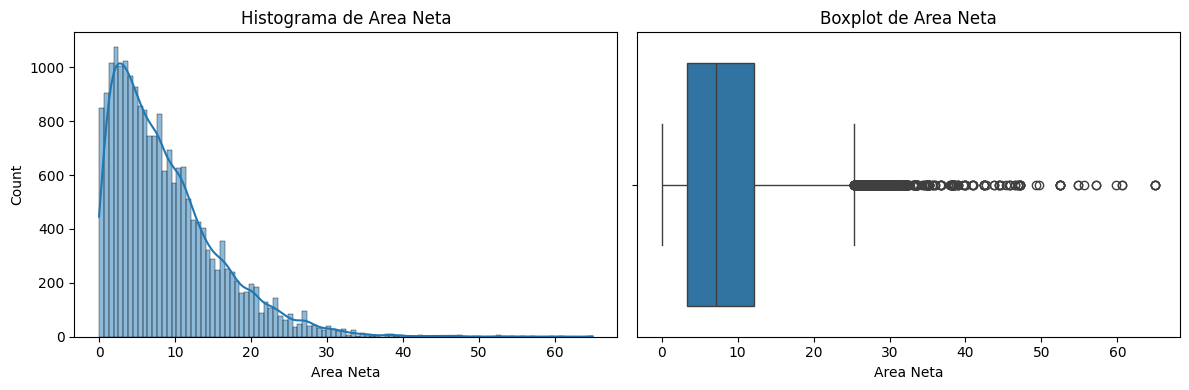

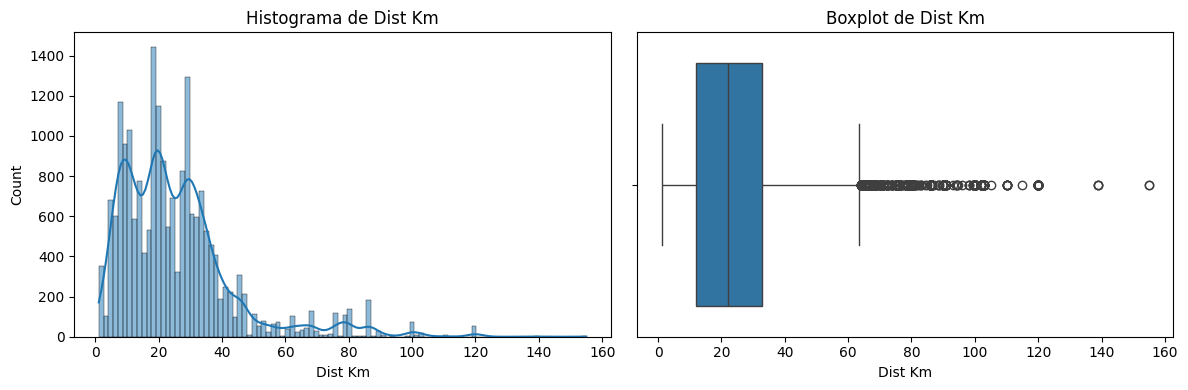

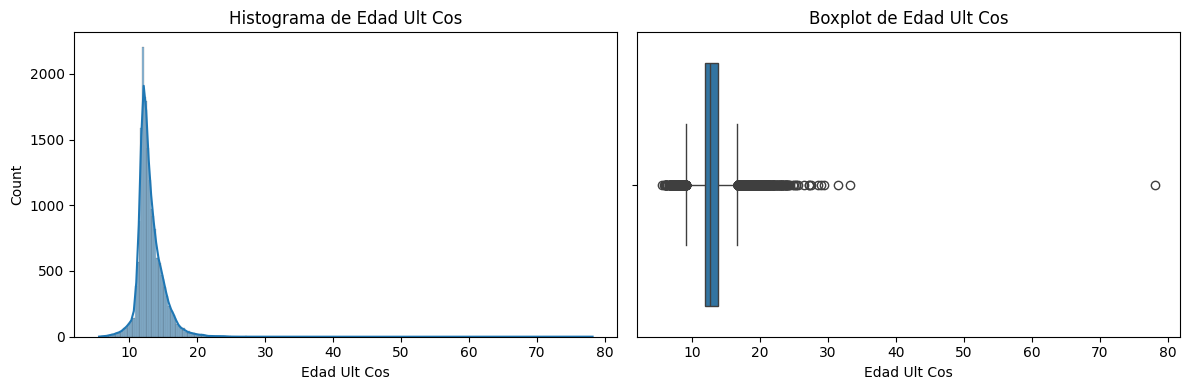

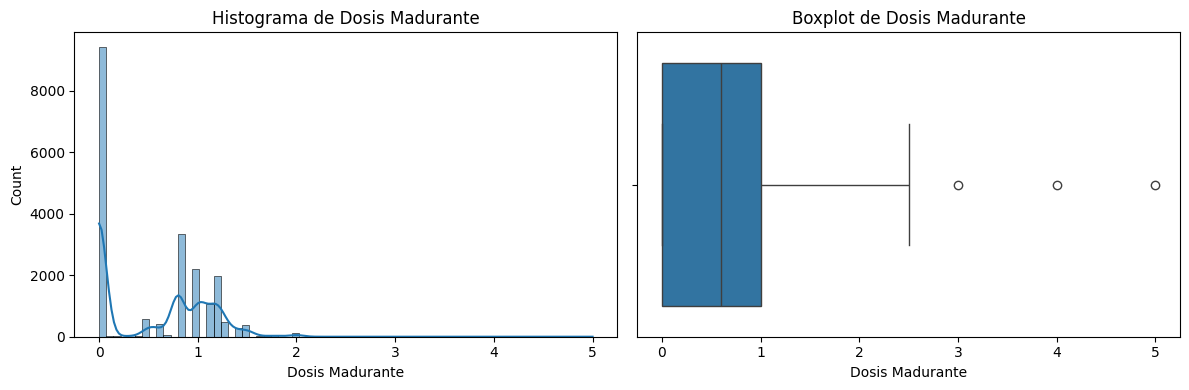

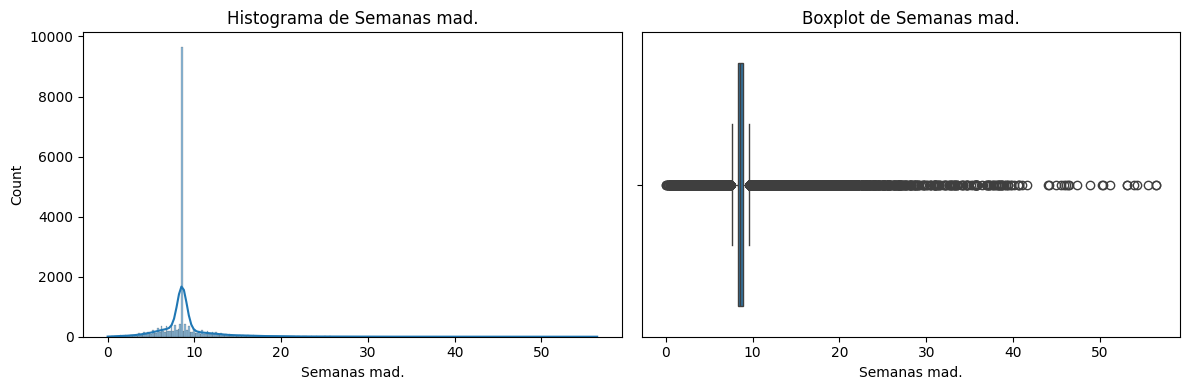

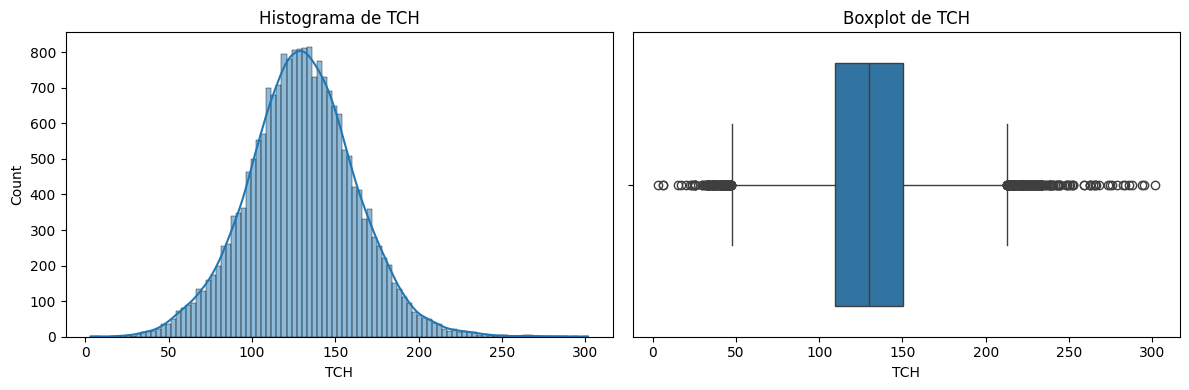

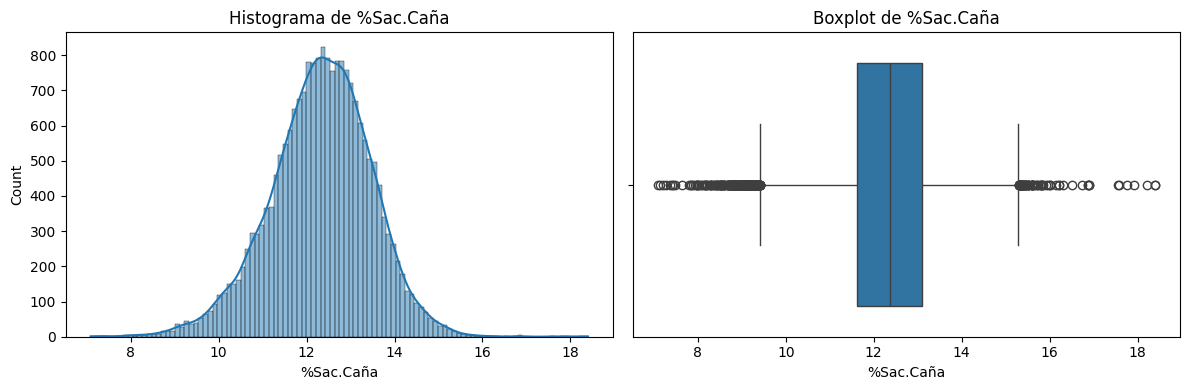

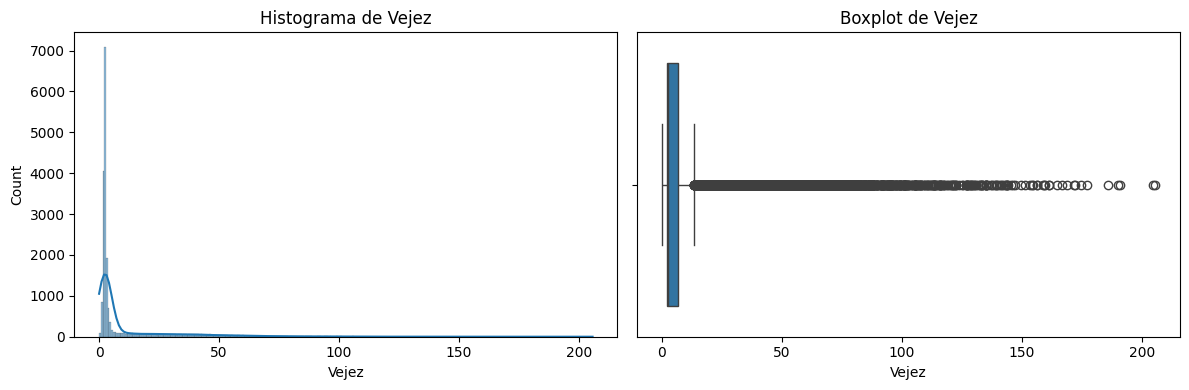

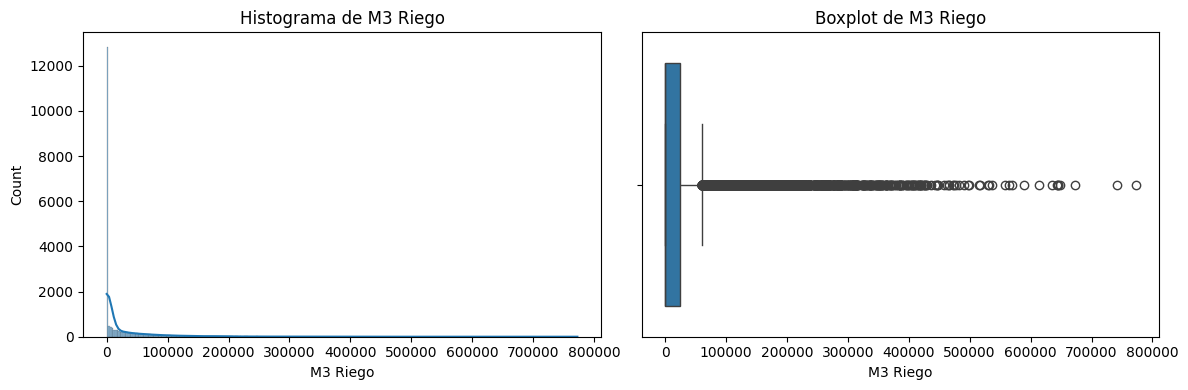

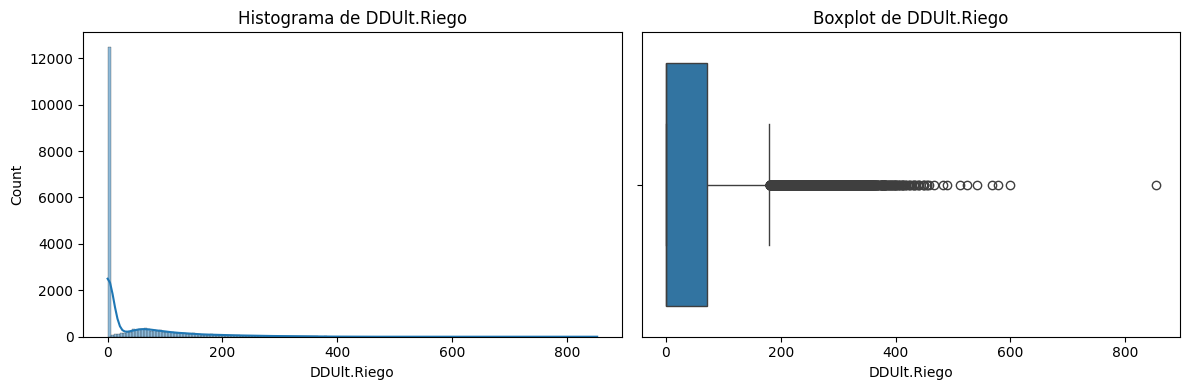

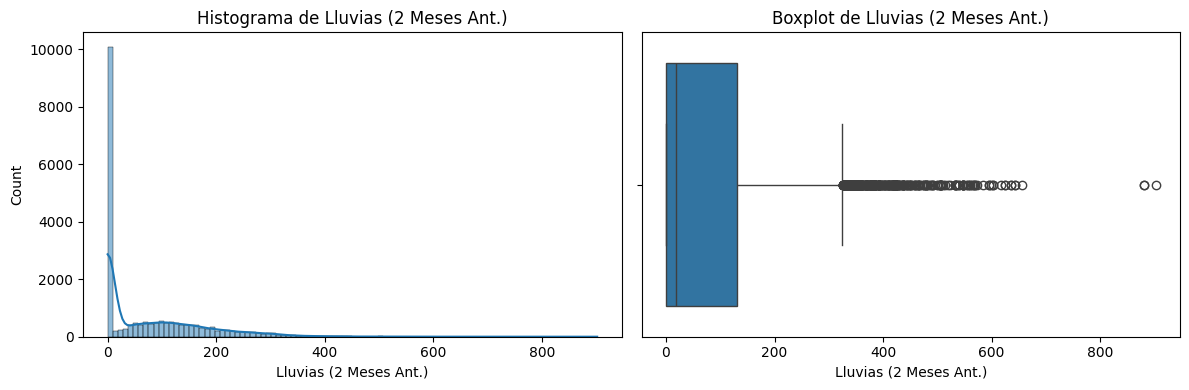

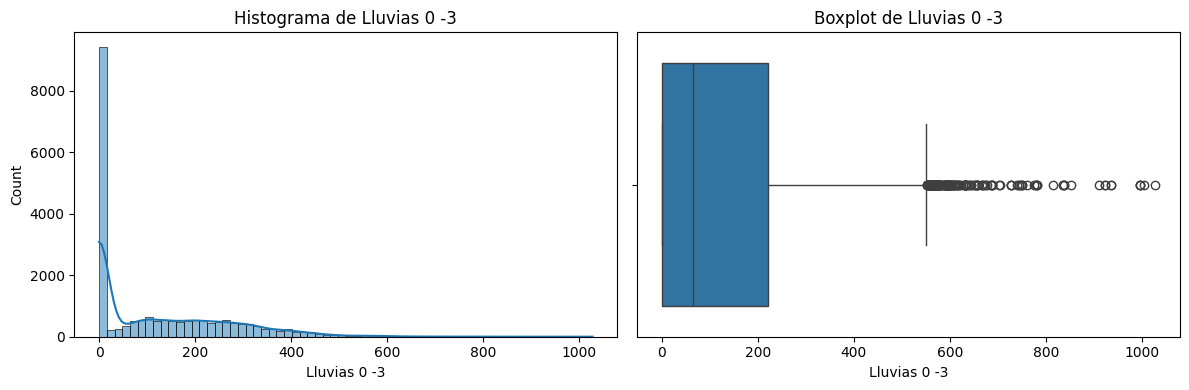

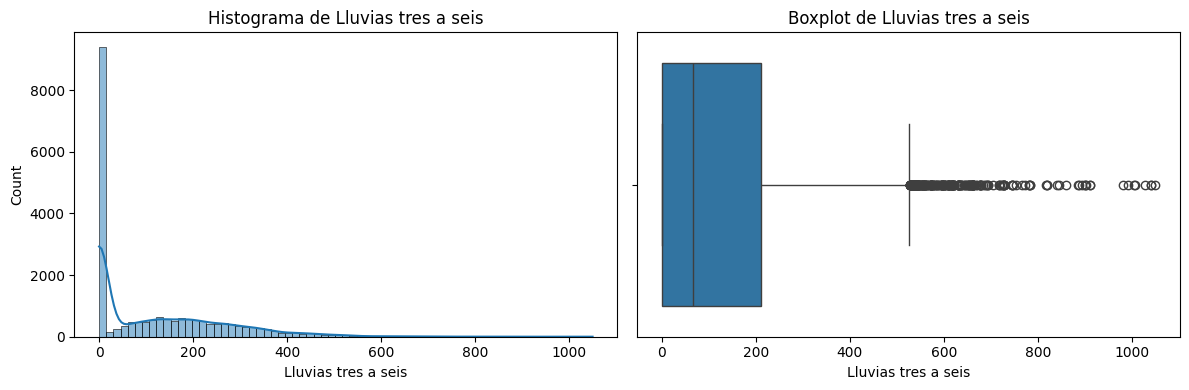

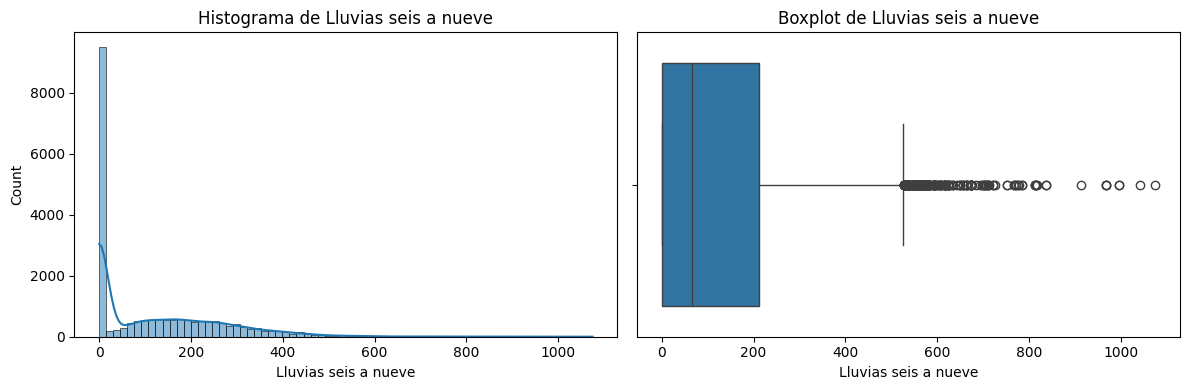

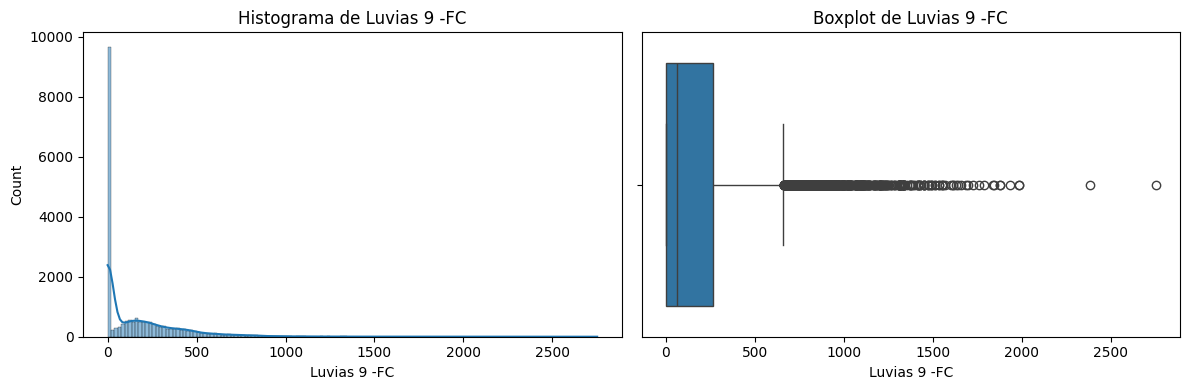

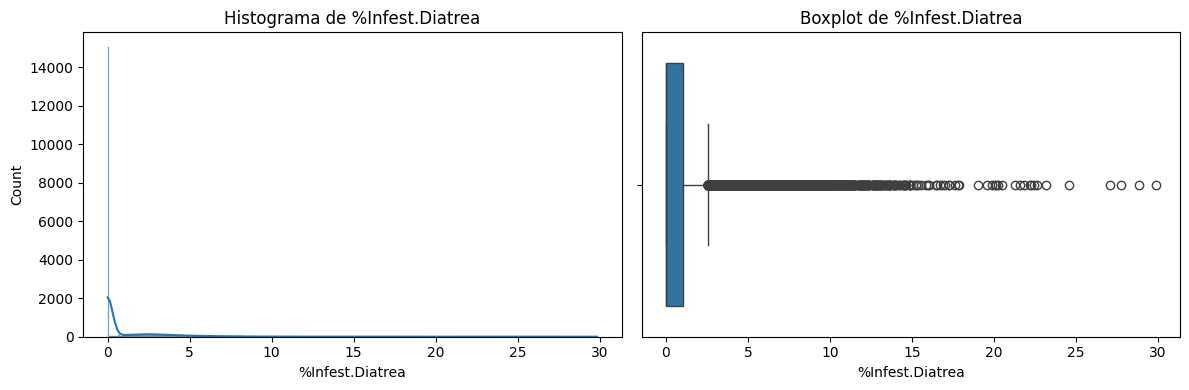

In [221]:
# Variables numéricas a revisar individualmente
cols_numericas = [
    'Area Neta',
    'Dist Km',
    'Edad Ult Cos',
    'Dosis Madurante',
    'Semanas mad.',
    'TCH',
    '%Sac.Caña',
    'Vejez',
    'M3 Riego',
    'DDUlt.Riego',
    'Lluvias (2 Meses Ant.)',
    'Lluvias 0 -3',
    'Lluvias tres a seis',
    'Lluvias seis a nueve',
    'Luvias 9 -FC',
    '%Infest.Diatrea'
]

for col in cols_numericas:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    sns.histplot(df_reg_sacarosa[col], kde=True, ax=axes[0])
    axes[0].set_title(f'Histograma de {col}')
    axes[0].set_xlabel(col)

    sns.boxplot(x=df_reg_sacarosa[col], ax=axes[1])
    axes[1].set_title(f'Boxplot de {col}')
    axes[1].set_xlabel(col)

    plt.tight_layout()
    plt.show()

Se realizó un análisis exploratorio de las variables categóricas con el fin de obtener mayor claridad sobre sus categorías, su distribución dentro del dataset y la posible presencia de valores atípicos, inconsistencias o categorías poco representativas. Este paso permitió comprender mejor la estructura de las variables cualitativas antes de evaluar su relación con las variables objetivo del modelo.

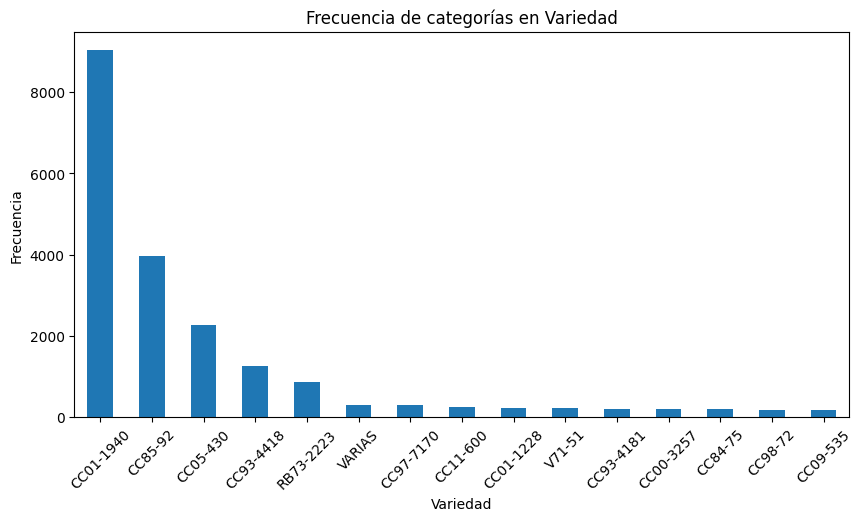

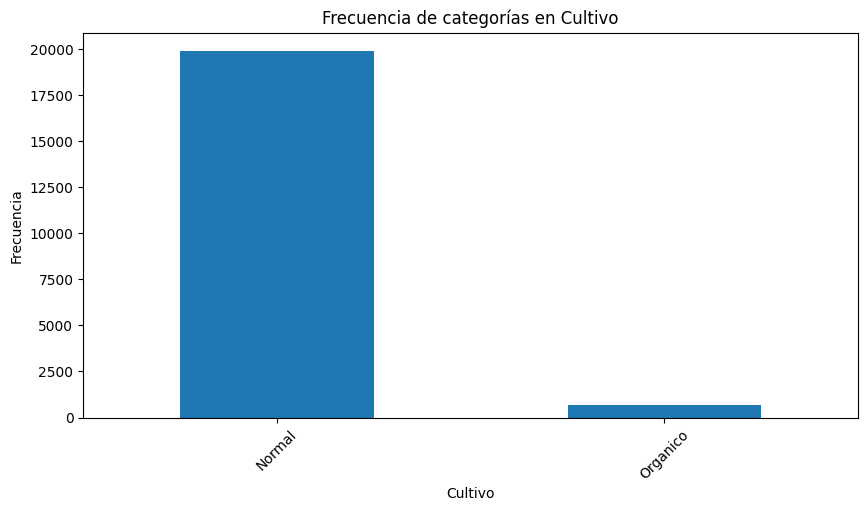

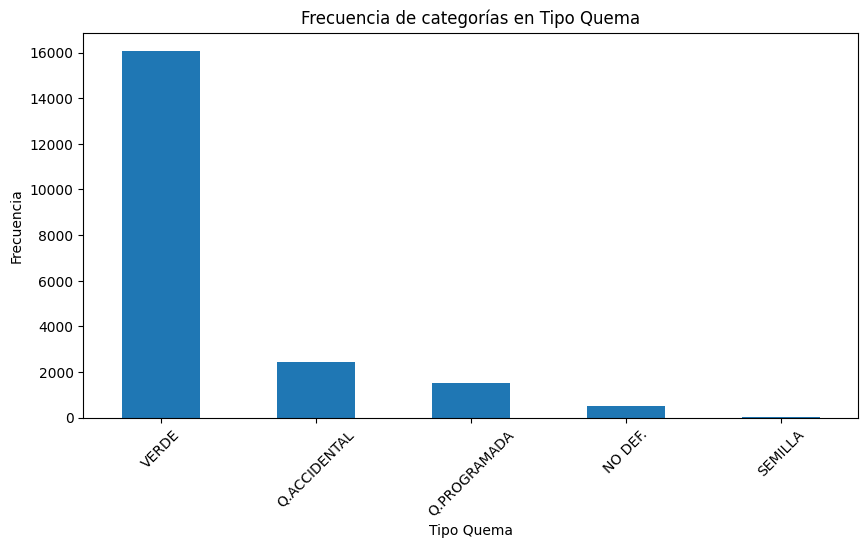

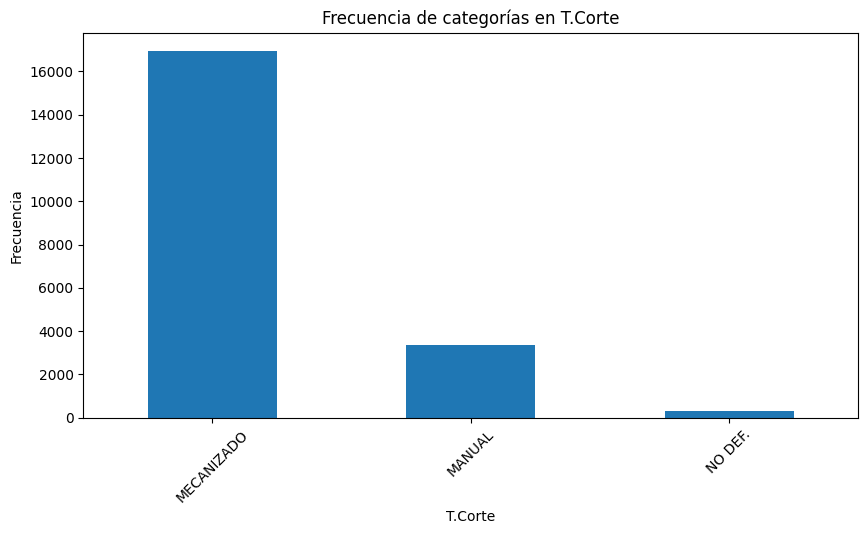

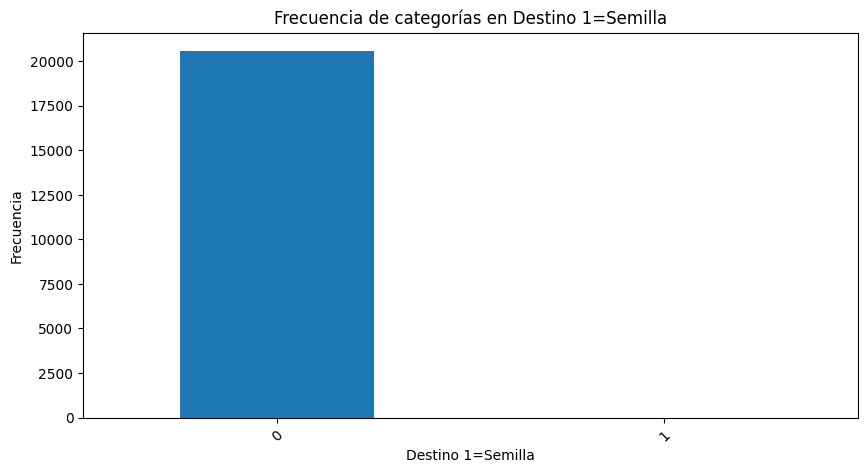

In [222]:
cols_categoricas = [
    'Variedad',
    'Cultivo',
    'Tipo Quema',
    'T.Corte',
    'Destino 1=Semilla'
]

for col in cols_categoricas:
    plt.figure(figsize=(10,5))
    df_reg_sacarosa[col].value_counts().head(15).plot(kind='bar')
    plt.title(f'Frecuencia de categorías en {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.xticks(rotation=45)
    plt.show()

Gracias al analisis visual, nos dimos cuenta que aunque la variable Destino 1=Semilla presentaba dos categorías en el dataset original, al construir el subconjunto de datos para el análisis de %Sac.Caña quedó prácticamente sin variabilidad, ya que solo un registro pertenecía a la categoría 1. Debido a esta pérdida de representatividad, se decidió excluirla del análisis de sacarosa, dado que no permitía realizar comparaciones confiables ni aportaba valor predictivo significativo en este subconjunto.

In [223]:
df_reg_sacarosa = df_reg_sacarosa.drop(columns=['Destino 1=Semilla'], errors='ignore')

print("Nuevo número de columnas:", df_reg_sacarosa.shape[1])

Nuevo número de columnas: 20


## Analisis de variables objetivos 

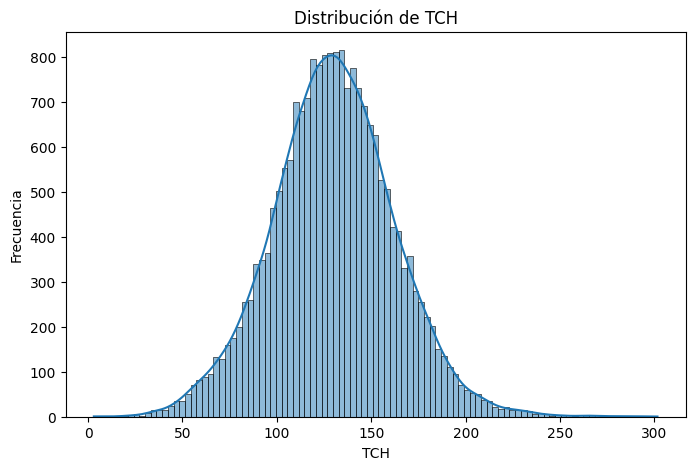

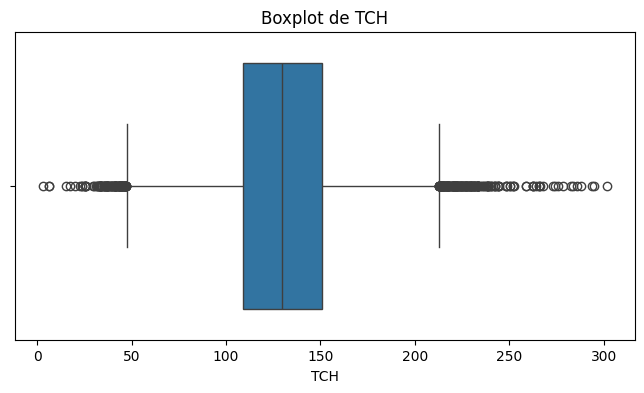

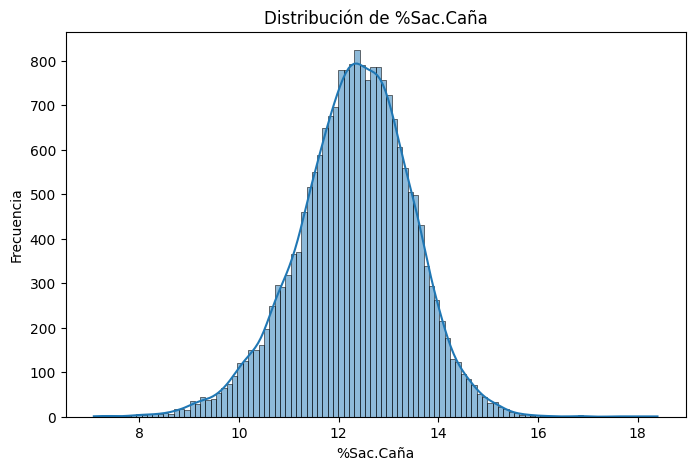

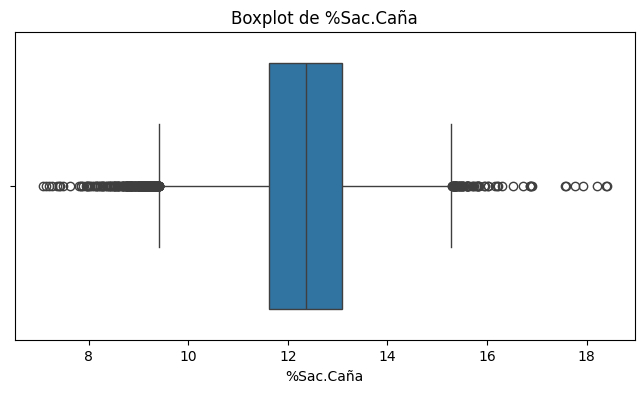

In [224]:
plt.figure(figsize=(8,5))
sns.histplot(df_reg_sacarosa['TCH'], kde=True)
plt.title('Distribución de TCH')
plt.xlabel('TCH')
plt.ylabel('Frecuencia')
plt.show()

# Boxplot TCH
plt.figure(figsize=(8,4))
sns.boxplot(x=df_reg_sacarosa['TCH'])
plt.title('Boxplot de TCH')
plt.xlabel('TCH')
plt.show()

# Histograma %Sac.Caña
plt.figure(figsize=(8,5))
sns.histplot(df_reg_sacarosa['%Sac.Caña'], kde=True)
plt.title('Distribución de %Sac.Caña')
plt.xlabel('%Sac.Caña')
plt.ylabel('Frecuencia')
plt.show()

# Boxplot %Sac.Caña
plt.figure(figsize=(8,4))
sns.boxplot(x=df_reg_sacarosa['%Sac.Caña'])
plt.title('Boxplot de %Sac.Caña')
plt.xlabel('%Sac.Caña')
plt.show()

In [225]:
stats_resumen = pd.DataFrame({
    'TCH': [
        df_reg_sacarosa['TCH'].mean(),
        df_reg_sacarosa['TCH'].median(),
        df_reg_sacarosa['TCH'].min(),
        df_reg_sacarosa['TCH'].max(),
        df_reg_sacarosa['TCH'].quantile(0.01),
        df_reg_sacarosa['TCH'].quantile(0.05),
        df_reg_sacarosa['TCH'].quantile(0.25),
        df_reg_sacarosa['TCH'].quantile(0.50),
        df_reg_sacarosa['TCH'].quantile(0.75),
        df_reg_sacarosa['TCH'].quantile(0.95),
        df_reg_sacarosa['TCH'].quantile(0.99),
    ],
    '%Sac.Caña': [
        df_reg_sacarosa['%Sac.Caña'].mean(),
        df_reg_sacarosa['%Sac.Caña'].median(),
        df_reg_sacarosa['%Sac.Caña'].min(),
        df_reg_sacarosa['%Sac.Caña'].max(),
        df_reg_sacarosa['%Sac.Caña'].quantile(0.01),
        df_reg_sacarosa['%Sac.Caña'].quantile(0.05),
        df_reg_sacarosa['%Sac.Caña'].quantile(0.25),
        df_reg_sacarosa['%Sac.Caña'].quantile(0.50),
        df_reg_sacarosa['%Sac.Caña'].quantile(0.75),
        df_reg_sacarosa['%Sac.Caña'].quantile(0.95),
        df_reg_sacarosa['%Sac.Caña'].quantile(0.99),
    ]
}, index=[
    'Media', 'Mediana', 'Mínimo', 'Máximo',
    'P1', 'P5', 'P25', 'P50', 'P75', 'P95', 'P99'
])

print(stats_resumen)

                TCH  %Sac.Caña
Media    130.029833  12.320202
Mediana  129.770210  12.370650
Mínimo     3.055379   7.086000
Máximo   301.608000  18.400000
P1        53.758831   9.304885
P5        76.367360  10.329955
P25      109.219883  11.619000
P50      129.770210  12.370650
P75      150.563464  13.087500
P95      182.800732  14.064915
P99      210.689285  14.849153


La variable TCH presenta una media de 130.03 y una mediana de 129.77, lo que sugiere una distribución relativamente centrada. Sin embargo, sus valores extremos van desde 3.06 hasta 301.61, y los percentiles muestran que la mayor parte de los registros se concentra por debajo de 210.69, lo que indica la presencia de outliers en ambos extremos.

En el caso de %Sac.Caña, la media (12.32) y la mediana (12.37) también son muy cercanas, lo que refleja una distribución equilibrada y menos dispersa que la de TCH. Sus valores se encuentran más concentrados, con el 99% de los datos por debajo de 14.85, aunque se observan algunos registros extremos que alcanzan 18.40.

### Correlacion de variables numericas

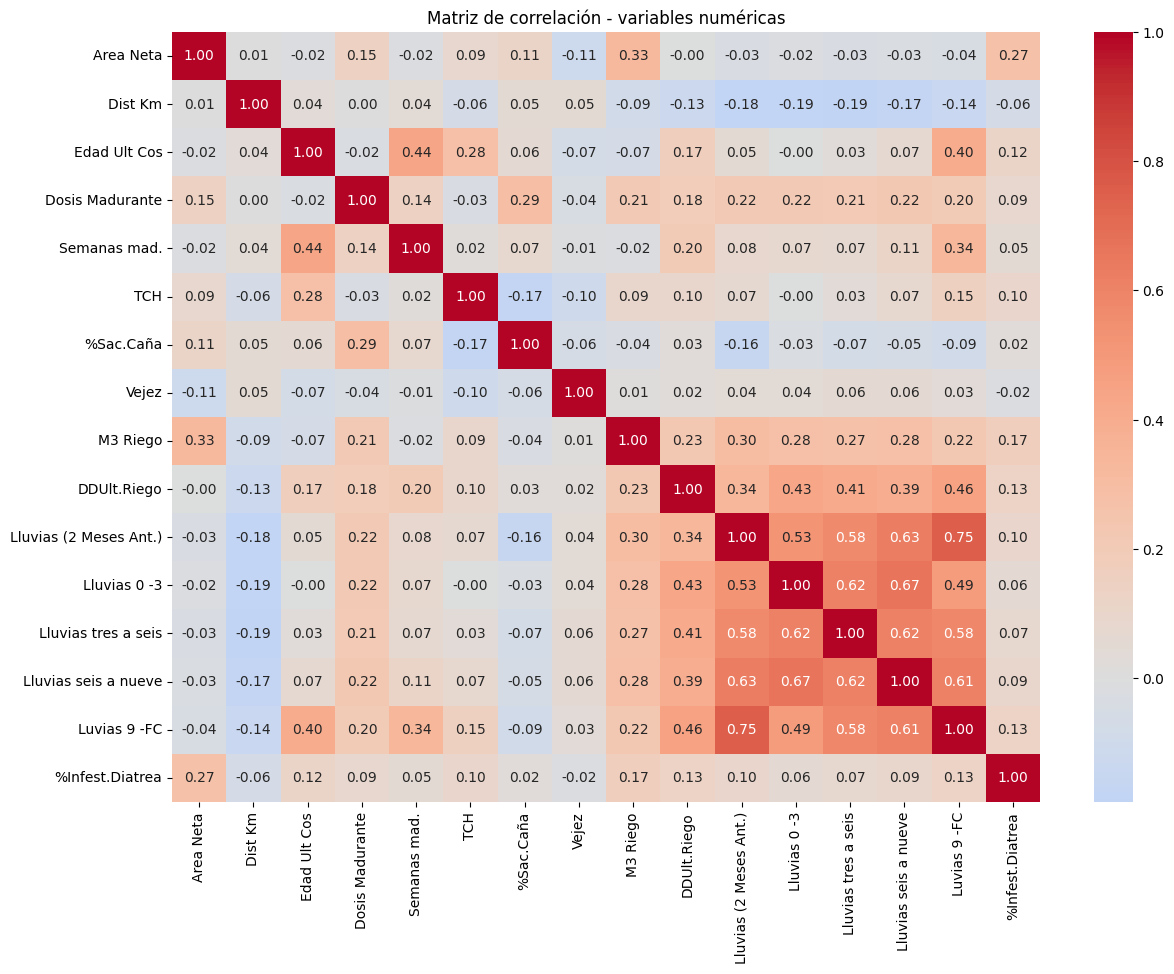

In [226]:
cols_num = [
    'Area Neta',
    'Dist Km',
    'Edad Ult Cos',
    'Dosis Madurante',
    'Semanas mad.',
    'TCH',
    '%Sac.Caña',
    'Vejez',
    'M3 Riego',
    'DDUlt.Riego',
    'Lluvias (2 Meses Ant.)',
    'Lluvias 0 -3',
    'Lluvias tres a seis',
    'Lluvias seis a nueve',
    'Luvias 9 -FC',
    '%Infest.Diatrea'
]

corr_matrix = df_reg_sacarosa[cols_num].corr()
plt.figure(figsize=(14,10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Matriz de correlación - variables numéricas')
plt.show()

La matriz de correlación mostró que no existen relaciones lineales fuertes entre una sola variable predictora y las variables objetivo, lo cual es esperable en un problema agrícola donde el rendimiento y la calidad del cultivo dependen de múltiples factores que interactúan entre sí. No obstante, se identificaron asociaciones moderadas y coherentes con el contexto del negocio. En el caso de TCH, las variable con mayor relación fue Edad Ult Cos, mientras que para %Sac.Caña destacó Dosis Madurante, además de relaciones negativas con variables de lluvia reciente. Estos resultados sugieren que el comportamiento de las variables objetivo no depende de un solo factor aislado, sino de combinaciones de variables agronómicas, climáticas y de manejo.

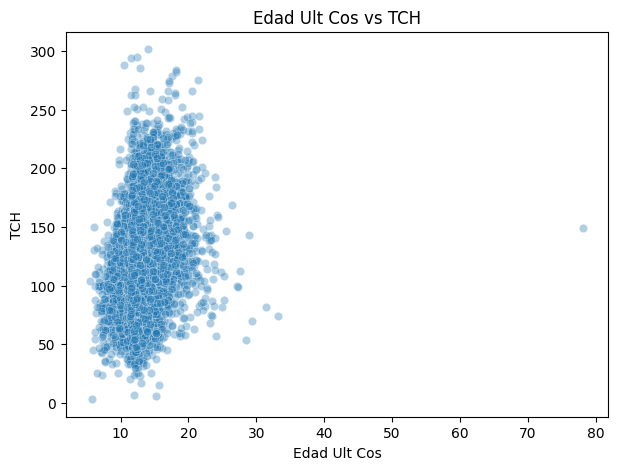

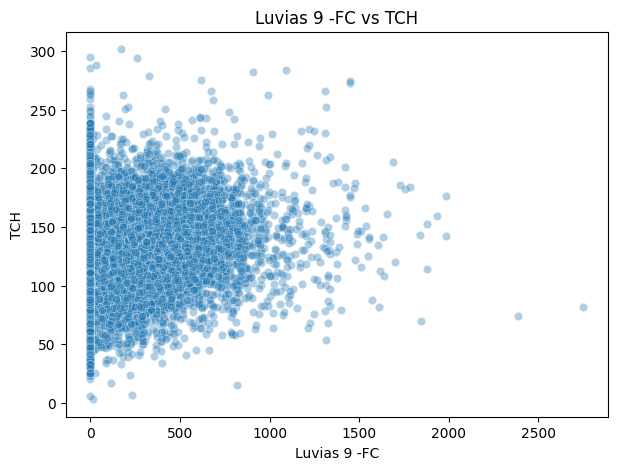

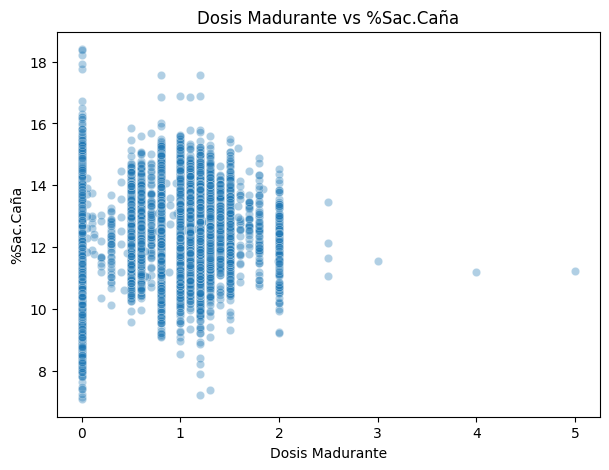

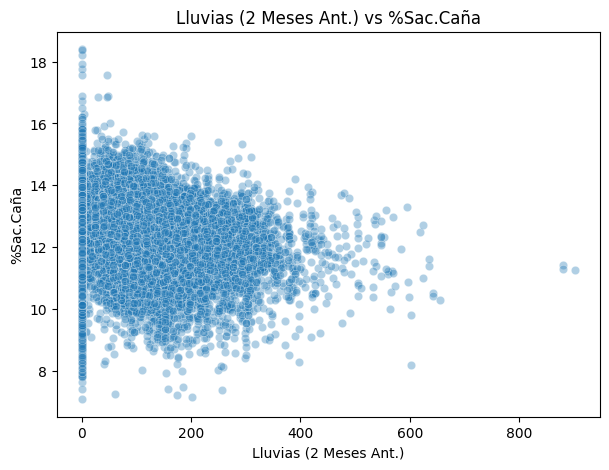

In [227]:
# 1) Edad Ult Cos vs TCH
plt.figure(figsize=(7,5))
sns.scatterplot(data=df_reg_sacarosa, x='Edad Ult Cos', y='TCH', alpha=0.35)
plt.title('Edad Ult Cos vs TCH')
plt.xlabel('Edad Ult Cos')
plt.ylabel('TCH')
plt.show()

# 2) Luvias 9 -FC vs TCH
plt.figure(figsize=(7,5))
sns.scatterplot(data=df_reg_sacarosa, x='Luvias 9 -FC', y='TCH', alpha=0.35)
plt.title('Luvias 9 -FC vs TCH')
plt.xlabel('Luvias 9 -FC')
plt.ylabel('TCH')
plt.show()

# 3) Dosis Madurante vs %Sac.Caña
plt.figure(figsize=(7,5))
sns.scatterplot(data=df_reg_sacarosa, x='Dosis Madurante', y='%Sac.Caña', alpha=0.35)
plt.title('Dosis Madurante vs %Sac.Caña')
plt.xlabel('Dosis Madurante')
plt.ylabel('%Sac.Caña')
plt.show()

# 4) Lluvias (2 Meses Ant.) vs %Sac.Caña
plt.figure(figsize=(7,5))
sns.scatterplot(data=df_reg_sacarosa, x='Lluvias (2 Meses Ant.)', y='%Sac.Caña', alpha=0.35)
plt.title('Lluvias (2 Meses Ant.) vs %Sac.Caña')
plt.xlabel('Lluvias (2 Meses Ant.)')
plt.ylabel('%Sac.Caña')
plt.show()



En todos los graficos se observó una tendencia positiva, aunque con alta dispersión.



### Variables categoricas


Por último, se analizaron las variables categóricas en relación con las variables objetivo, para entender cómo se comportan sus distintas categorías y tener una visión más clara de su posible influencia sobre TCH y %Sac.Caña.

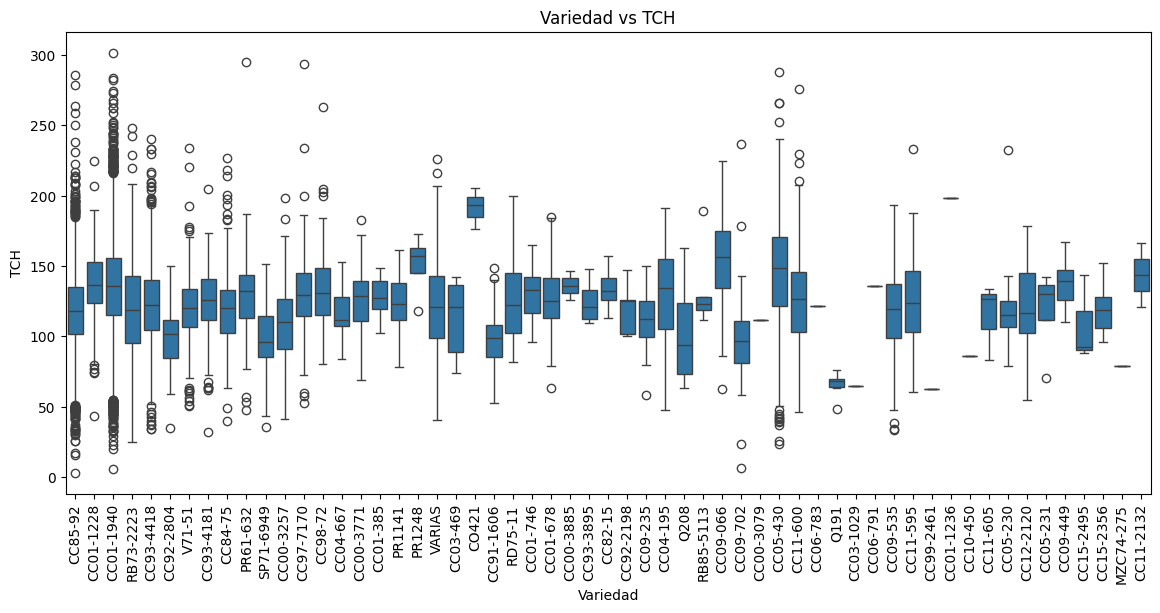

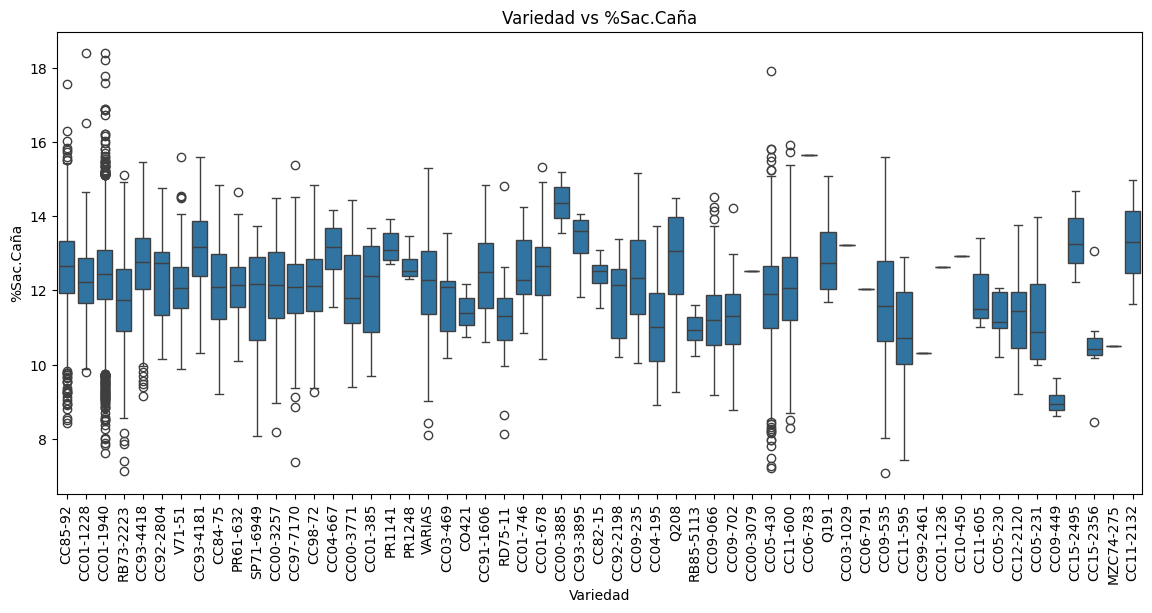

In [228]:
plt.figure(figsize=(14,6))
sns.boxplot(data=df_reg_sacarosa, x='Variedad', y='TCH')
plt.title('Variedad vs TCH')
plt.xticks(rotation=90)
plt.show()

plt.figure(figsize=(14,6))
sns.boxplot(data=df_reg_sacarosa, x='Variedad', y='%Sac.Caña')
plt.title('Variedad vs %Sac.Caña')
plt.xticks(rotation=90)
plt.show()

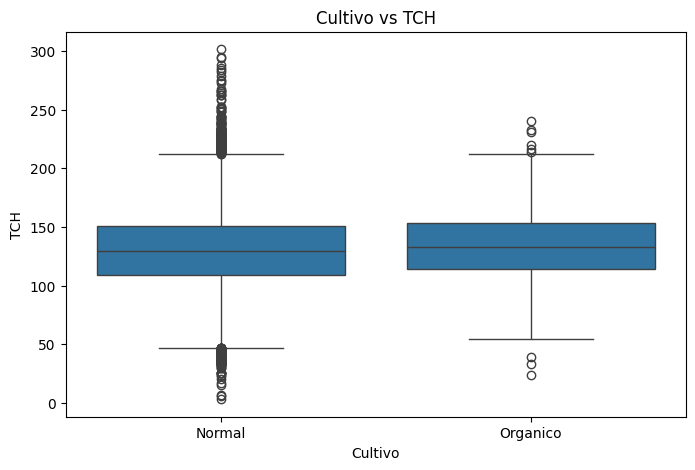

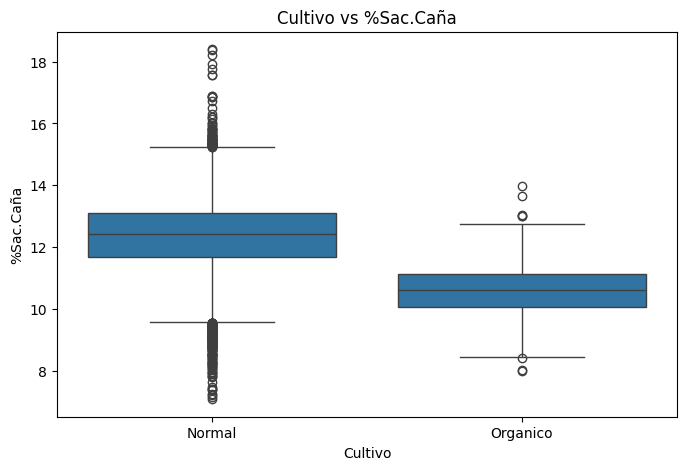

In [229]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df_reg_sacarosa, x='Cultivo', y='TCH')
plt.title('Cultivo vs TCH')
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(data=df_reg_sacarosa, x='Cultivo', y='%Sac.Caña')
plt.title('Cultivo vs %Sac.Caña')
plt.show()

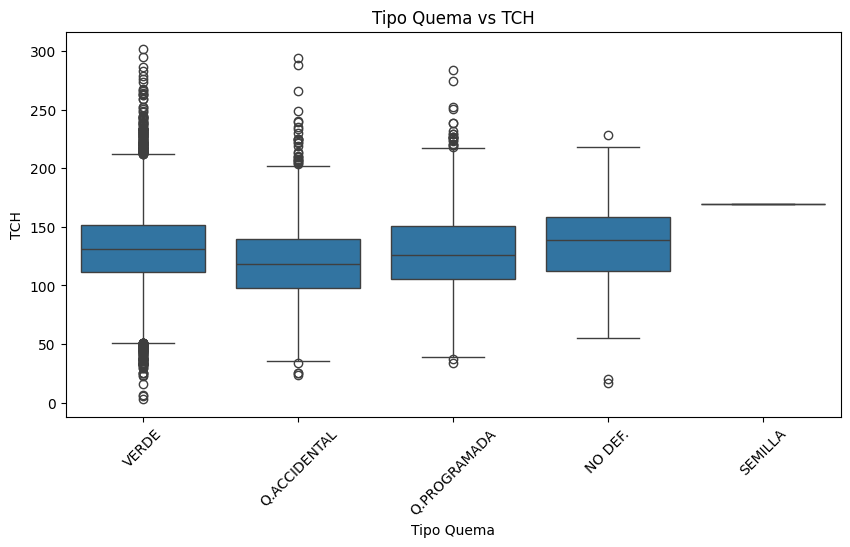

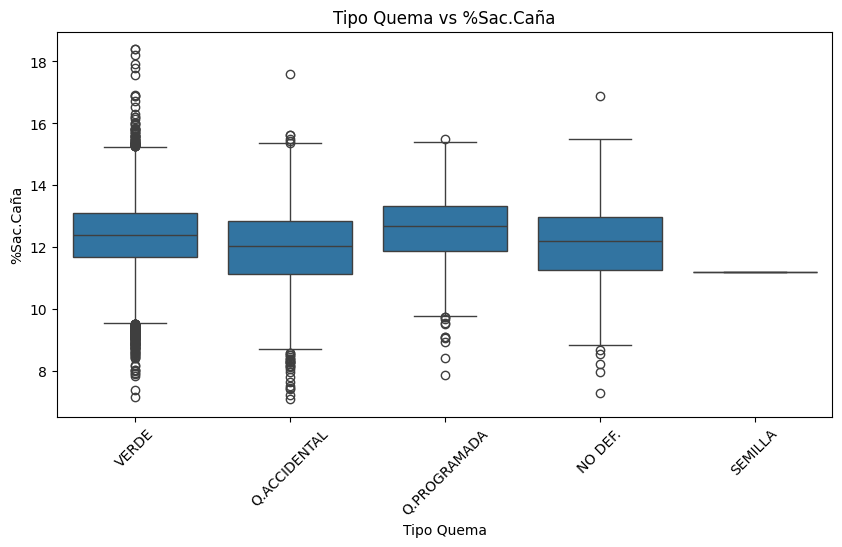

In [230]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df_reg_sacarosa, x='Tipo Quema', y='TCH')
plt.title('Tipo Quema vs TCH')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10,5))
sns.boxplot(data=df_reg_sacarosa, x='Tipo Quema', y='%Sac.Caña')
plt.title('Tipo Quema vs %Sac.Caña')
plt.xticks(rotation=45)
plt.show()

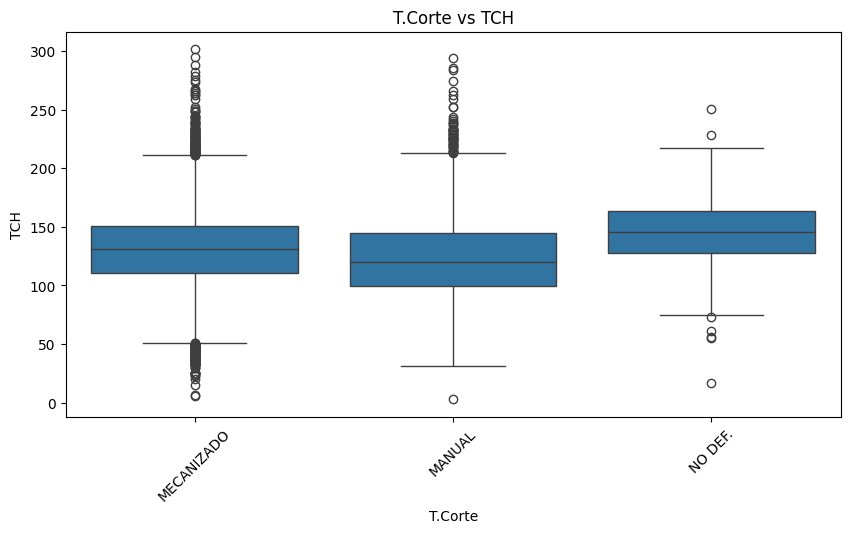

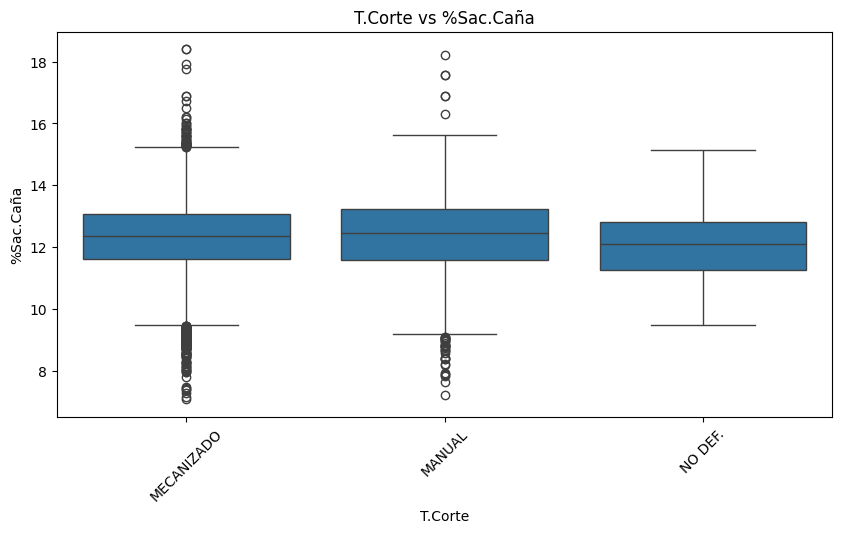

In [231]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df_reg_sacarosa, x='T.Corte', y='TCH')
plt.title('T.Corte vs TCH')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10,5))
sns.boxplot(data=df_reg_sacarosa, x='T.Corte', y='%Sac.Caña')
plt.title('T.Corte vs %Sac.Caña')
plt.xticks(rotation=45)
plt.show()

# Analisis multicolinealidad

En el análisis de multicolinealidad mediante el VIF, se observó que la mayoría de las variables presentaban valores aceptables, lo que sugiere ausencia de redundancia fuerte entre los predictores. Las mayores asociaciones se dieron entre algunas variables de lluvia, lo cual es coherente dado que representan distintos momentos del ciclo del cultivo. Sin embargo, ninguno de estos valores alcanzó niveles críticos, por lo que no se consideró necesario eliminar más variables en esta etapa.

In [232]:
# Variables numéricas candidatas para el modelo de regresión
cols_vif = [
    'Area Neta',
    'Dist Km',
    'Edad Ult Cos',
    'Dosis Madurante',
    'Semanas mad.',
    'Vejez',
    'M3 Riego',
    'DDUlt.Riego',
    'Lluvias (2 Meses Ant.)',
    'Lluvias 0 -3',
    'Lluvias tres a seis',
    'Lluvias seis a nueve',
    'Luvias 9 -FC',
    '%Infest.Diatrea'
]

# Tomamos solo esas columnas
X_vif = df_reg_sacarosa[cols_vif].copy()


# Agregar constante
X_vif = sm.add_constant(X_vif)

# Calcular VIF
vif_data = pd.DataFrame()
vif_data['Variable'] = X_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

# Ordenar de mayor a menor
vif_data = vif_data.sort_values(by='VIF', ascending=False)

print(vif_data)

                  Variable        VIF
0                    const  77.444506
13            Luvias 9 -FC   4.241326
9   Lluvias (2 Meses Ant.)   3.161414
12    Lluvias seis a nueve   2.452536
10            Lluvias 0 -3   2.178385
11     Lluvias tres a seis   2.133817
3             Edad Ult Cos   1.685990
8              DDUlt.Riego   1.429833
5             Semanas mad.   1.364683
7                 M3 Riego   1.344615
1                Area Neta   1.258811
4          Dosis Madurante   1.146483
14         %Infest.Diatrea   1.126488
2                  Dist Km   1.069888
6                    Vejez   1.033534


# Variables seleccionadas para la prediccion de variables tch %Sac

Las variables seleccionadas fueron las siguientes;

* Area Neta: representa el tamaño útil del lote y puede relacionarse con manejo y productividad.

* Dist Km: captura una condición logística/espacial que podría asociarse indirectamente al comportamiento del cultivo.

* Variedad: refleja diferencias genéticas del material sembrado.

* Edad Ult Cos: resume el estado temporal del cultivo al cosecharse.

* Cultivo: diferencia entre manejo normal y orgánico.

* Dosis Madurante: se relaciona especialmente con la calidad y concentración de sacarosa.

* Semanas mad.: representa la duración del proceso de maduración.

* TonUltCorte: aporta historial productivo del lote.

* Vejez: actúa como indicador del estado del cultivo en etapas finales.

* Tipo Quema y T.Corte: recogen decisiones de manejo de cosecha.

* M3 Riego y DDUlt.Riego: representan el manejo hídrico.

* Lluvias (...): capturan condiciones climáticas por etapas del ciclo.

* %Infest.Diatrea: incorpora la posible presión de plaga sobre el cultivo.

In [233]:
df_reg_sacarosa.info()

<class 'pandas.DataFrame'>
Index: 20578 entries, 0 to 20974
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Area Neta               20578 non-null  float64
 1   Dist Km                 20578 non-null  float64
 2   Variedad                20578 non-null  str    
 3   Edad Ult Cos            20578 non-null  float64
 4   Cultivo                 20578 non-null  str    
 5   Dosis Madurante         20578 non-null  float64
 6   Semanas mad.            20578 non-null  float64
 7   TCH                     20578 non-null  float64
 8   %Sac.Caña               20578 non-null  float64
 9   Vejez                   20578 non-null  float64
 10  Tipo Quema              20578 non-null  str    
 11  T.Corte                 20578 non-null  str    
 12  M3 Riego                20578 non-null  float64
 13  DDUlt.Riego             20578 non-null  int64  
 14  Lluvias (2 Meses Ant.)  20578 non-null  float64
 15  L

In [234]:
df_reg.info()

<class 'pandas.DataFrame'>
RangeIndex: 21027 entries, 0 to 21026
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Area Neta               21027 non-null  float64
 1   Dist Km                 21027 non-null  float64
 2   Variedad                21027 non-null  str    
 3   Edad Ult Cos            21027 non-null  float64
 4   Destino 1=Semilla       21027 non-null  int64  
 5   Cultivo                 21027 non-null  str    
 6   Dosis Madurante         21027 non-null  float64
 7   Semanas mad.            21027 non-null  float64
 8   TCH                     21027 non-null  float64
 9   %Sac.Caña               20578 non-null  float64
 10  Vejez                   21027 non-null  float64
 11  Tipo Quema              21027 non-null  str    
 12  T.Corte                 21027 non-null  str    
 13  M3 Riego                21027 non-null  float64
 14  DDUlt.Riego             21027 non-null  int64  
 

Para la fase de modelado se decidió trabajar con dos subconjuntos derivados del dataset de regresión. El primero fue destinado a la predicción de TCH, conservando los registros disponibles para esta variable objetivo y excluyendo %Sac.Caña del conjunto de predictores. El segundo se orientó a la predicción de %Sac.Caña, para lo cual se eliminaron los registros con valores faltantes en esta variable y, adicionalmente, se excluyó TCH como predictor. Esta decisión se tomó con el fin de evitar el uso de variables objetivo cruzadas dentro del mismo modelo y mantener una formulación más limpia, interpretable y coherente con un escenario real de predicción.

Asimismo, en el subconjunto destinado a %Sac.Caña se descartó la variable Destino 1=Semilla, dado que tras el filtrado quedó prácticamente sin variabilidad, lo que limitaba su utilidad analítica y predictiva.

In [235]:
#Dataset de regresion de sacaraosa
from sklearn.preprocessing import LabelEncoder


# Copia de trabajo
df_sacarosa_final = df_reg_sacarosa.copy()

# Eliminar TCH porque aquí el target será %Sac.Caña
df_sacarosa_final = df_sacarosa_final.drop(columns=['TCH'], errors='ignore')

# Columnas categóricas a codificar
cols_categoricas = ['Variedad', 'Cultivo', 'Tipo Quema', 'T.Corte']

# Aplicar LabelEncoder
encoders = {}

for col in cols_categoricas:
    le = LabelEncoder()
    df_sacarosa_final[col] = le.fit_transform(df_sacarosa_final[col])
    encoders[col] = le

# Guardar dataset final
PROCESSED_SACAROSA_PATH = '../data/processed/datos_limpios_regresion_sacarosa.csv'
df_sacarosa_final.to_csv(PROCESSED_SACAROSA_PATH, index=False)

print("Dataset guardado en:", PROCESSED_SACAROSA_PATH)
print("Shape final:", df_sacarosa_final.shape)
print(df_sacarosa_final.info())

Dataset guardado en: ../data/processed/datos_limpios_regresion_sacarosa.csv
Shape final: (20578, 19)
<class 'pandas.DataFrame'>
Index: 20578 entries, 0 to 20974
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Area Neta               20578 non-null  float64
 1   Dist Km                 20578 non-null  float64
 2   Variedad                20578 non-null  int64  
 3   Edad Ult Cos            20578 non-null  float64
 4   Cultivo                 20578 non-null  int64  
 5   Dosis Madurante         20578 non-null  float64
 6   Semanas mad.            20578 non-null  float64
 7   %Sac.Caña               20578 non-null  float64
 8   Vejez                   20578 non-null  float64
 9   Tipo Quema              20578 non-null  int64  
 10  T.Corte                 20578 non-null  int64  
 11  M3 Riego                20578 non-null  float64
 12  DDUlt.Riego             20578 non-null  int64  
 13  Lluvia

In [236]:
#Dataset de regresion de TCH
# Copia de trabajo
df_tch_final = df_reg.copy()

# Eliminar %Sac.Caña porque aquí el target será TCH
df_tch_final = df_tch_final.drop(columns=['%Sac.Caña'], errors='ignore')

# Si quieres, aquí también puedes quitar Destino 1=Semilla si ya decidieron no usarla
# df_tch_final = df_tch_final.drop(columns=['Destino 1=Semilla'], errors='ignore')

# Columnas categóricas a codificar
cols_categoricas = ['Variedad', 'Cultivo', 'Tipo Quema', 'T.Corte']

encoders_tch = {}

for col in cols_categoricas:
    le = LabelEncoder()
    df_tch_final[col] = le.fit_transform(df_tch_final[col])
    encoders_tch[col] = le

# Guardar dataset final
PROCESSED_TCH_PATH = '../data/processed/datos_limpios_regresion_tch.csv'
df_tch_final.to_csv(PROCESSED_TCH_PATH, index=False)

print("Dataset guardado en:", PROCESSED_TCH_PATH)
print("Shape final:", df_tch_final.shape)
print(df_tch_final.info())

Dataset guardado en: ../data/processed/datos_limpios_regresion_tch.csv
Shape final: (21027, 20)
<class 'pandas.DataFrame'>
RangeIndex: 21027 entries, 0 to 21026
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Area Neta               21027 non-null  float64
 1   Dist Km                 21027 non-null  float64
 2   Variedad                21027 non-null  int64  
 3   Edad Ult Cos            21027 non-null  float64
 4   Destino 1=Semilla       21027 non-null  int64  
 5   Cultivo                 21027 non-null  int64  
 6   Dosis Madurante         21027 non-null  float64
 7   Semanas mad.            21027 non-null  float64
 8   TCH                     21027 non-null  float64
 9   Vejez                   21027 non-null  float64
 10  Tipo Quema              21027 non-null  int64  
 11  T.Corte                 21027 non-null  int64  
 12  M3 Riego                21027 non-null  float64
 13  DDUlt.

# Analisis detallado BD_IPSA_1940

Recordemos como se encuentra la base de datos actualmente

In [237]:
df_clf.info()

<class 'pandas.DataFrame'>
RangeIndex: 2187 entries, 0 to 2186
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   NOME            2187 non-null   str    
 1   FAZ             2187 non-null   int64  
 2   TAL             2187 non-null   object 
 3   tipocorte       2187 non-null   str    
 4   variedad        2187 non-null   str    
 5   madurada        2187 non-null   str    
 6   producto        2187 non-null   str    
 7   dosismad        2187 non-null   float64
 8   semsmad         2187 non-null   float64
 9   edad            2187 non-null   float64
 10  cortes          2187 non-null   int64  
 11  me              2187 non-null   float64
 12  vejez           2187 non-null   float64
 13  sacarosa        2187 non-null   float64
 14  mes             2187 non-null   int64  
 15  periodo         2187 non-null   int64  
 16  TCH             2187 non-null   int64  
 17  lluvias         2187 non-null   int64  
 18 

Para el dataset de clasificación, una vez eliminadas las variables identificadoras (NOME, FAZ, Grupo de tenencia y TAL), ademas se elimino la variable periodo, ya que puede que el pasar de los años se presente una tendencia, pero no sabemos que paso ese año para que incrementara o dismunuyan las dos variables objetivos.

Se decidió excluir la variable mes, ya que, aunque representa el momento del registro o la cosecha, su aporte explicativo se consideró limitado frente a otras variables más directas del contexto productivo, como las relacionadas con lluvias, maduración y manejo del cultivo. En este sentido, mes se interpretó como una referencia temporal general cuya información podía quedar parcialmente contenida en variables agronómicas más específicas.
 
Se obtuvo un conjunto de variables con potencial utilidad predictiva para clasificar el desempeño del cultivo. A diferencia del dataset de regresión, este conjunto no presentaba valores faltantes, por lo que el trabajo se centró principalmente en la interpretación de las variables y en la definición de las clases objetivo a partir de TCH y sacarosa. A partir de este punto, el análisis continúa con la construcción de las categorías de desempeño y la preparación de subconjuntos específicos para cada problema de clasificación


In [238]:
cols_identificadores_clf = [
    'NOME',
    'FAZ',
    'TAL',
    'grupo_tenencia',
    'periodo',
    'mes'
]

df_clf = df_clf.drop(columns=cols_identificadores_clf, errors='ignore')

print("Columnas identificadoras eliminadas en clasificación:")
print(cols_identificadores_clf)
print("Nuevo número de columnas en clasificación:", df_clf.shape[1])
print(df_clf.info())

Columnas identificadoras eliminadas en clasificación:
['NOME', 'FAZ', 'TAL', 'grupo_tenencia', 'periodo', 'mes']
Nuevo número de columnas en clasificación: 14
<class 'pandas.DataFrame'>
RangeIndex: 2187 entries, 0 to 2186
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   tipocorte    2187 non-null   str    
 1   variedad     2187 non-null   str    
 2   madurada     2187 non-null   str    
 3   producto     2187 non-null   str    
 4   dosismad     2187 non-null   float64
 5   semsmad      2187 non-null   float64
 6   edad         2187 non-null   float64
 7   cortes       2187 non-null   int64  
 8   me           2187 non-null   float64
 9   vejez        2187 non-null   float64
 10  sacarosa     2187 non-null   float64
 11  TCH          2187 non-null   int64  
 12  lluvias      2187 non-null   int64  
 13  pct_diatrea  2187 non-null   float64
dtypes: float64(7), int64(3), str(4)
memory usage: 239.3 KB
None


# Analisis profundo del dataset

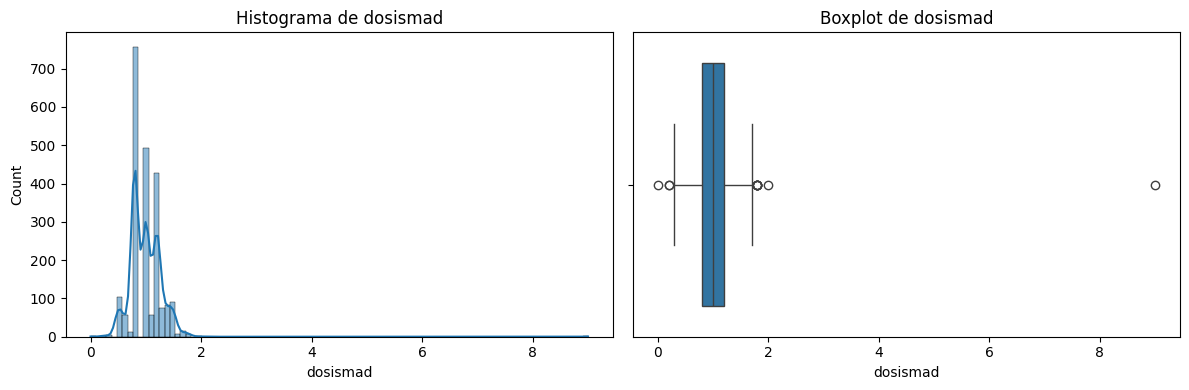

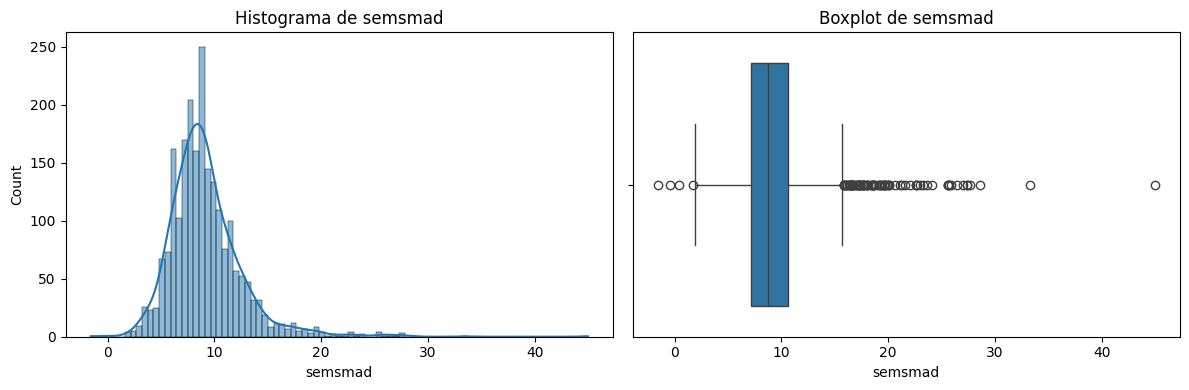

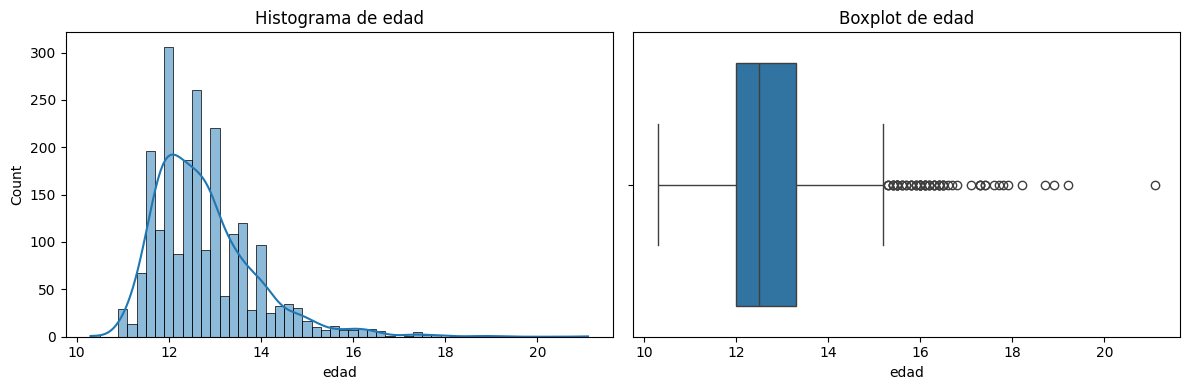

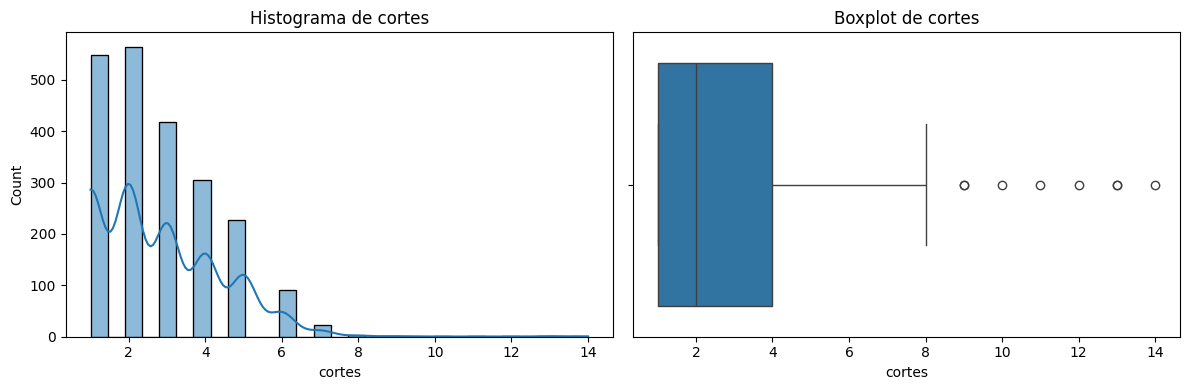

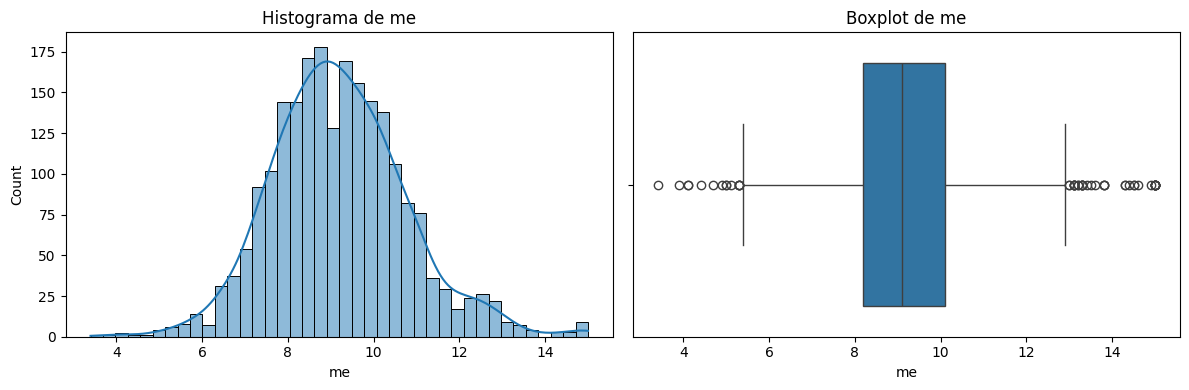

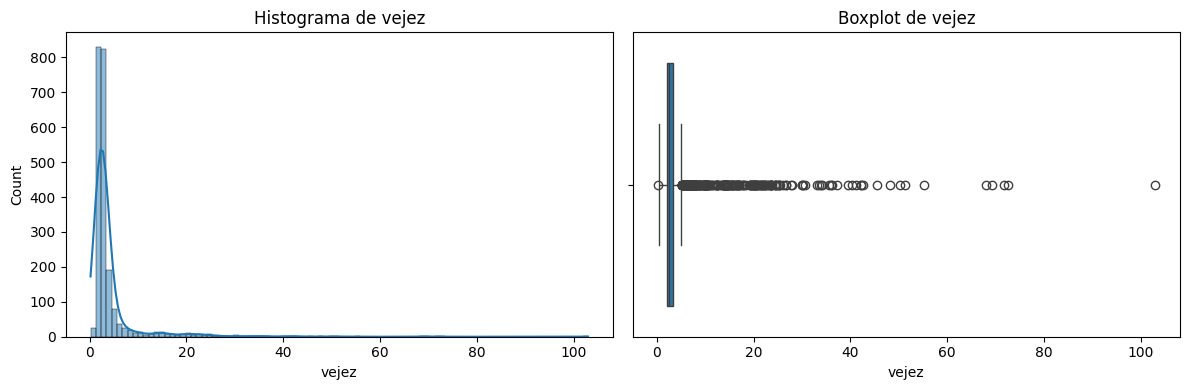

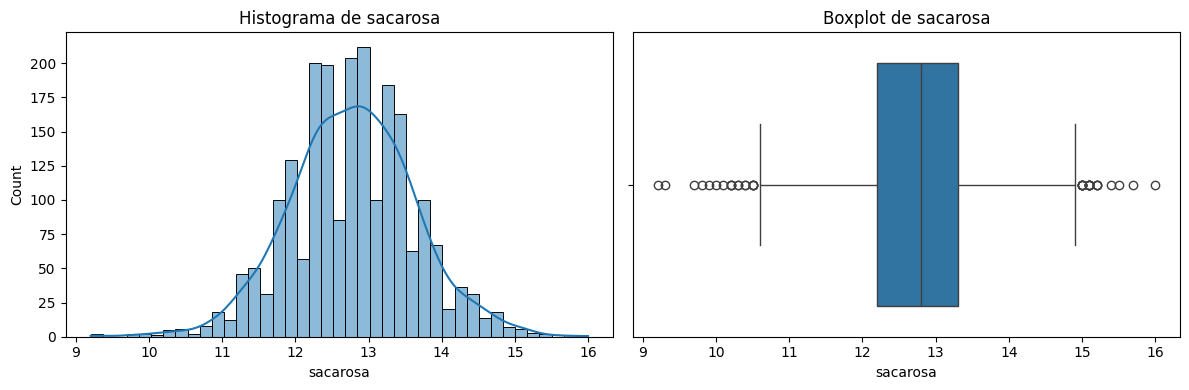

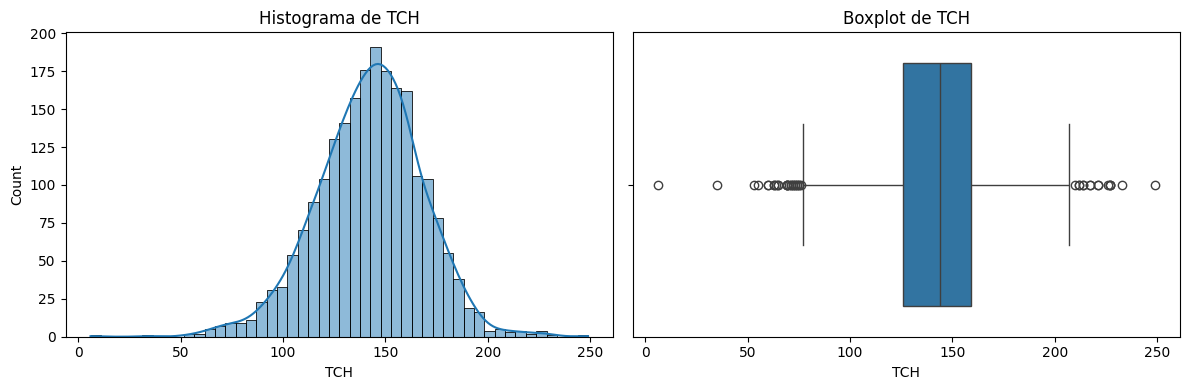

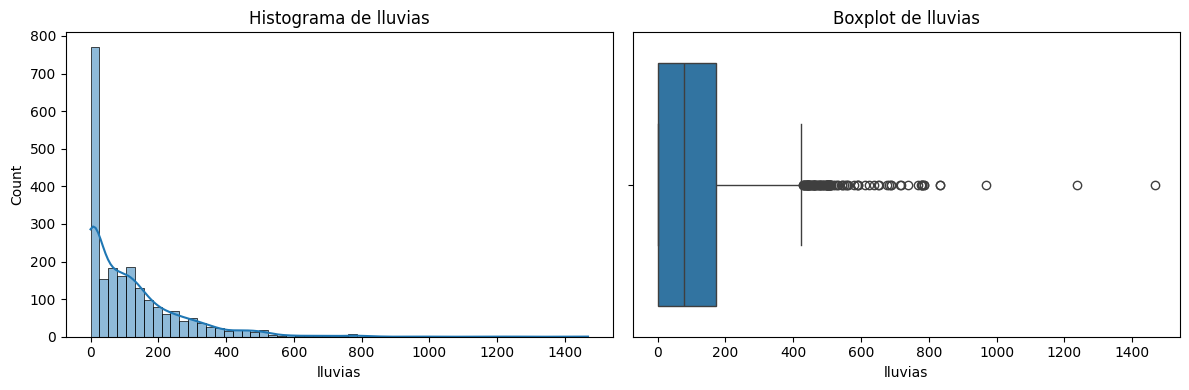

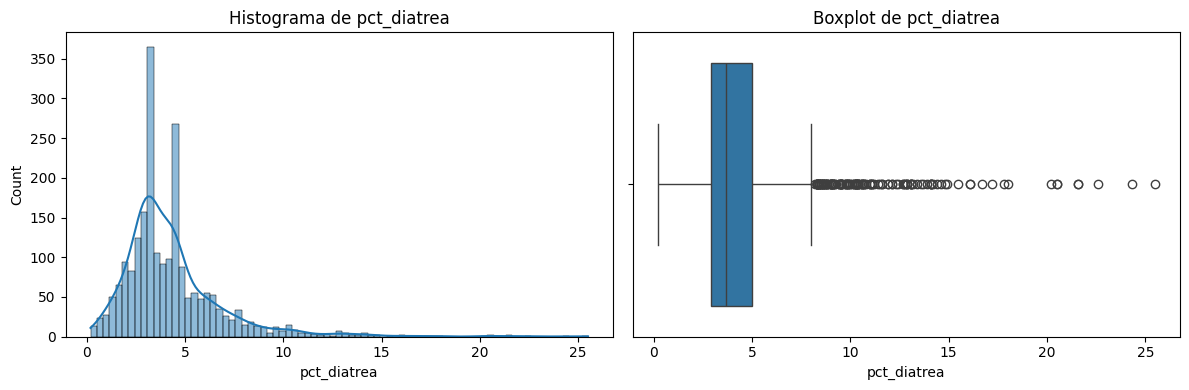

In [239]:
cols_numericas_clf = [
    'dosismad', 'semsmad', 'edad', 'cortes', 'me', 'vejez',
    'sacarosa', 'TCH', 'lluvias','pct_diatrea'
]

for col in cols_numericas_clf:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    sns.histplot(df_clf[col], kde=True, ax=axes[0])
    axes[0].set_title(f'Histograma de {col}')

    sns.boxplot(x=df_clf[col], ax=axes[1])
    axes[1].set_title(f'Boxplot de {col}')

    plt.tight_layout()
    plt.show()

En la variable vejez se identificó un valor extremo claramente aislado (102.9) respecto al comportamiento del resto de la distribución. Debido a ello, se consideró como un registro atípico sospechoso y se reemplazó por un valor imputado mediante la mediana, con el fin de reducir su posible distorsión sobre el análisis sin alterar de forma excesiva la variabilidad general de la variable.

In [240]:
df_clf.loc[df_clf['vejez'] > 100, 'vejez'] = pd.NA

mediana_vejez = df_clf['vejez'].median()
df_clf['vejez'] = df_clf['vejez'].fillna(mediana_vejez)

print("Mediana usada:", mediana_vejez)
print(df_clf['vejez'].describe())

Mediana usada: 2.6
count    2187.000000
mean        4.126292
std         5.977145
min         0.200000
25%         2.100000
50%         2.600000
75%         3.300000
max        72.500000
Name: vejez, dtype: float64


# Analisis Variables categoricas

In [241]:
cols_categoricas_clf = ['tipocorte', 'variedad', 'madurada', 'producto']

for col in cols_categoricas_clf:
    print(f"\n===== {col} =====")
    print("Número de categorías:", df_clf[col].nunique())
    print(df_clf[col].value_counts(dropna=False).head(30))


===== tipocorte =====
Número de categorías: 1
tipocorte
Mecanizado Verde    2187
Name: count, dtype: int64

===== variedad =====
Número de categorías: 1
variedad
CC01-1940    2187
Name: count, dtype: int64

===== madurada =====
Número de categorías: 1
madurada
SI    2187
Name: count, dtype: int64

===== producto =====
Número de categorías: 1
producto
BONUS 250 EC REGULADOR FISIOLÓGICO    2187
Name: count, dtype: int64


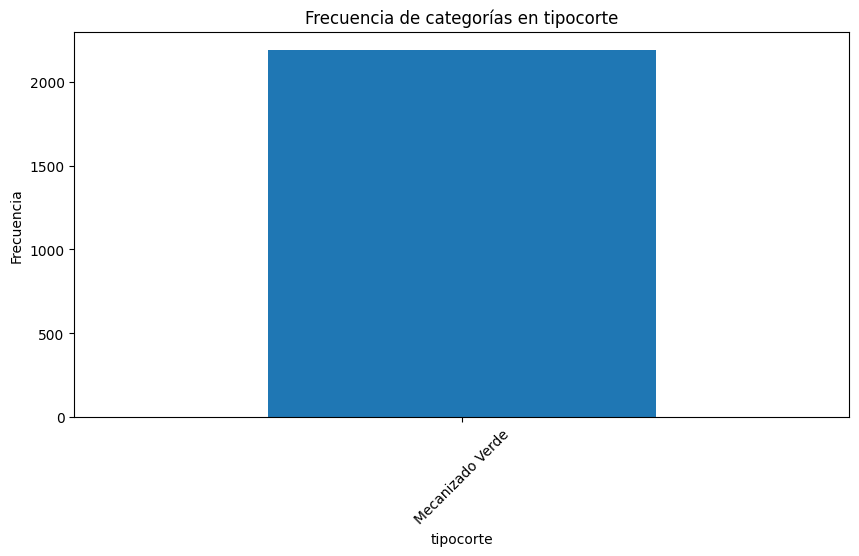

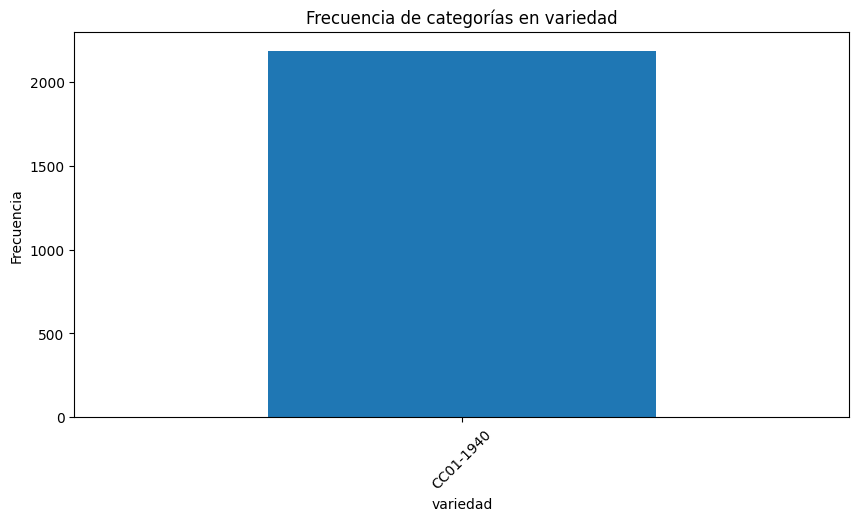

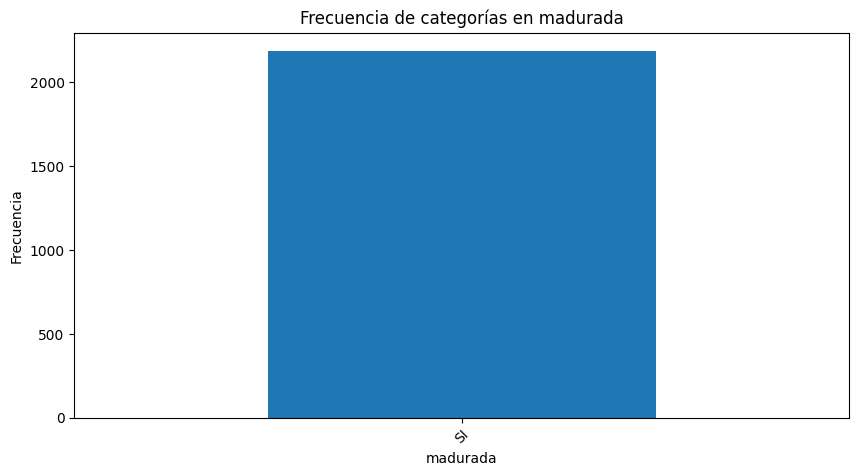

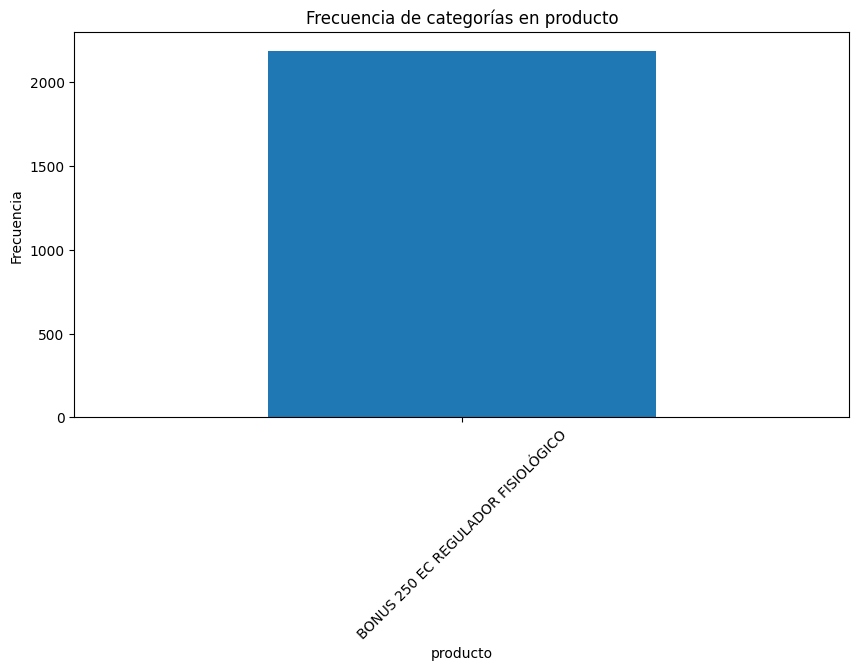

In [242]:
for col in cols_categoricas_clf:
    plt.figure(figsize=(10,5))
    df_clf[col].value_counts().head(20).plot(kind='bar')
    plt.title(f'Frecuencia de categorías en {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')
    plt.xticks(rotation=45)
    plt.show()

Se eliminaron las variables tipocorte, variedad, madurada y producto debido a que no presentaban variabilidad dentro del dataset, es decir, todos los registros pertenecían a una única categoría en cada caso. Por esta razón, no aportaban capacidad discriminativa para los modelos de clasificación y su inclusión no generaba valor predictivo.

In [243]:
cols_sin_variabilidad = [
    'tipocorte',
    'variedad',
    'madurada',
    'producto'
]

df_clf = df_clf.drop(columns=cols_sin_variabilidad, errors='ignore')

print("Columnas eliminadas por no tener variabilidad:")
print(cols_sin_variabilidad)
print("Nuevo número de columnas:", df_clf.shape[1])
print(df_clf.info())

Columnas eliminadas por no tener variabilidad:
['tipocorte', 'variedad', 'madurada', 'producto']
Nuevo número de columnas: 10
<class 'pandas.DataFrame'>
RangeIndex: 2187 entries, 0 to 2186
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   dosismad     2187 non-null   float64
 1   semsmad      2187 non-null   float64
 2   edad         2187 non-null   float64
 3   cortes       2187 non-null   int64  
 4   me           2187 non-null   float64
 5   vejez        2187 non-null   float64
 6   sacarosa     2187 non-null   float64
 7   TCH          2187 non-null   int64  
 8   lluvias      2187 non-null   int64  
 9   pct_diatrea  2187 non-null   float64
dtypes: float64(7), int64(3)
memory usage: 171.0 KB
None


El análisis univariado de las variables objetivo del dataset de clasificación mostró que tanto TCH como sacarosa presentan distribuciones unimodales y razonablemente estables. En el caso de TCH, se observó una mayor dispersión y algunos valores atípicos en ambos extremos, lo que sugiere variabilidad real en la productividad de los lotes. Por su parte, sacarosa mostró una distribución más concentrada, con menor dispersión y valores generalmente agrupados en un rango más estrecho. En ambos casos, los valores extremos no fueron eliminados de forma automática, ya que pueden corresponder a comportamientos reales del cultivo y no necesariamente a errores de registro. Estas características respaldan el uso de ambas variables para la construcción posterior de clases de desempeño.

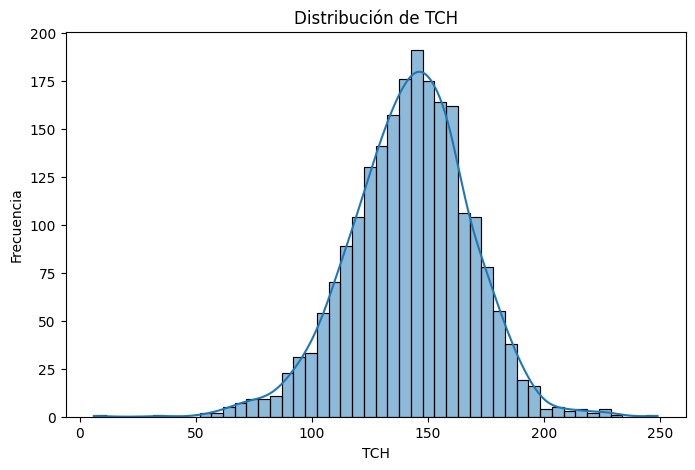

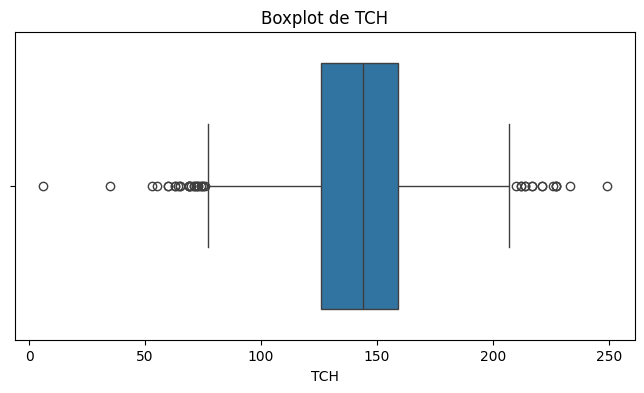

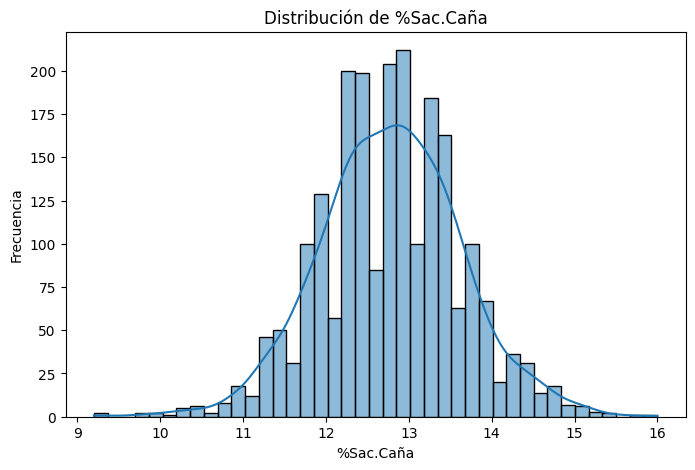

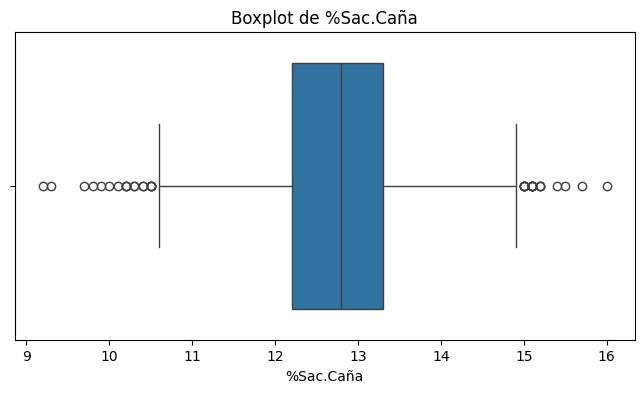

In [244]:
plt.figure(figsize=(8,5))
sns.histplot(df_clf['TCH'], kde=True)
plt.title('Distribución de TCH')
plt.xlabel('TCH')
plt.ylabel('Frecuencia')
plt.show()

# Boxplot TCH
plt.figure(figsize=(8,4))
sns.boxplot(x=df_clf['TCH'])
plt.title('Boxplot de TCH')
plt.xlabel('TCH')
plt.show()

# Histograma %Sac.Caña
plt.figure(figsize=(8,5))
sns.histplot(df_clf['sacarosa'], kde=True)
plt.title('Distribución de %Sac.Caña')
plt.xlabel('%Sac.Caña')
plt.ylabel('Frecuencia')
plt.show()

# Boxplot %Sac.Caña
plt.figure(figsize=(8,4))
sns.boxplot(x=df_clf['sacarosa'])
plt.title('Boxplot de %Sac.Caña')
plt.xlabel('%Sac.Caña')
plt.show()

## Matriz Correlacion

La matriz de correlación mostró que no existen relaciones lineales fuertes entre las variables predictoras y las variables objetivo. En el caso de TCH, la relación más visible fue negativa con cortes y positiva con edad, mientras que para sacarosa destacó una relación negativa con me y lluvias, y una relación positiva, aunque débil, con semsmad. Además, se observó una correlación negativa entre TCH y sacarosa, lo que sugiere que productividad y calidad no necesariamente aumentan al mismo tiempo

                  TCH  sacarosa
TCH          1.000000 -0.207086
edad         0.150832 -0.043997
pct_diatrea  0.105009 -0.090487
lluvias      0.050599 -0.158616
dosismad     0.028478 -0.006872
me           0.007890 -0.278591
semsmad     -0.012170  0.092324
vejez       -0.076993 -0.032396
sacarosa    -0.207086  1.000000
cortes      -0.230539  0.040351


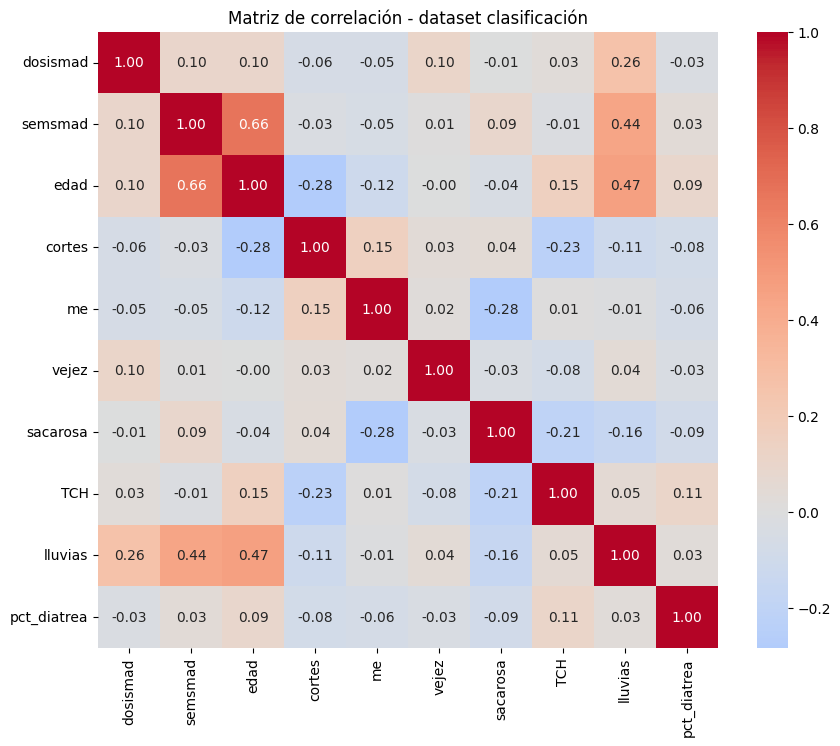

In [245]:
cols_numericas_clf = [
    'dosismad', 'semsmad', 'edad', 'cortes', 'me',
    'vejez', 'sacarosa', 'TCH', 'lluvias', 'pct_diatrea'
]

corr_clf = df_clf[cols_numericas_clf].corr(numeric_only=True)

print(corr_clf[['TCH', 'sacarosa']].sort_values(by='TCH', ascending=False))

plt.figure(figsize=(10,8))
sns.heatmap(corr_clf, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Matriz de correlación - dataset clasificación')
plt.show()

## Analisis multicolinealidad

El análisis de multicolinealidad mediante el VIF mostró que las variables numéricas del dataset de clasificación no presentan problemas importantes de redundancia. Todos los predictores registraron valores bajos, cercanos a 1, y el valor más alto correspondió a edad con 2.20, seguido de semsmad con 1.97. En consecuencia, no se identificó necesidad de eliminar variables por colinealidad en esta etapa.

In [246]:
# Variables numéricas candidatas para el modelo de regresión
cols_vif = [
    'dosismad', 'semsmad', 'edad', 'cortes', 'me', 'vejez',
    'lluvias','pct_diatrea'
]

# Tomamos solo esas columnas
X_vif = df_clf[cols_vif].copy()



# Agregar constante
X_vif = sm.add_constant(X_vif)

# Calcular VIF
vif_data = pd.DataFrame()
vif_data['Variable'] = X_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

# Ordenar de mayor a menor
vif_data = vif_data.sort_values(by='VIF', ascending=False)

print(vif_data)

      Variable         VIF
0        const  301.556629
3         edad    2.196283
2      semsmad    1.965138
7      lluvias    1.419079
4       cortes    1.167757
1     dosismad    1.092020
5           me    1.037419
8  pct_diatrea    1.017124
6        vejez    1.014244


# Variables seleccionadas para la prediccion de variables tch %Sac

Después del análisis de multicolinealidad, se decidió conservar las variables dosismad, semsmad, edad, cortes, me, vejez, lluvias y pct_diatrea, ya que todas presentaron valores de VIF bajos y aceptables, lo que indica ausencia de redundancia fuerte entre ellas. Esto significa que cada una aporta información propia al modelo y no está explicada en exceso por las demás variables. Además, estas variables resultan relevantes desde el contexto del negocio, porque representan dimensiones importantes del cultivo como el manejo del madurante (dosismad, semsmad), el estado y desarrollo de la caña (edad, cortes, vejez, me), las condiciones climáticas (lluvias) y la presencia de plaga (pct_diatrea). En conjunto, conforman un grupo de predictores coherente y útil para los modelos de clasificación de TCH y sacarosa.

Para los modelos de clasificación se construyeron clases objetivo a partir de las variables continuas TCH y sacarosa. En ambos casos se utilizaron cuantiles (33% y 66%) para definir tres niveles de desempeño: bajo, medio y alto. Esta estrategia permitió obtener clases balanceadas y comparables, facilitando el entrenamiento de los modelos y evitando sesgos por desbalance de categorías. Posteriormente, para cada problema de clasificación se eliminó la variable continua original y también la otra variable objetivo, con el fin de evitar redundancia y mantener una formulación más limpia del modelo.

In [247]:
# Copia para clasificación de TCH
df_clf_tch = df_clf.copy()

# Crear clase objetivo de TCH en 3 niveles balanceados
df_clf_tch['Clase_TCH'] = pd.qcut(
    df_clf_tch['TCH'],
    q=[0, 0.33, 0.66, 1.0],
    labels=['Bajo', 'Medio', 'Alto']
)


umbrales_tch = df_clf_tch['TCH'].quantile([0, 0.33, 0.66, 1.0])
print("Umbrales TCH:")
print(umbrales_tch)

# Eliminar variables continuas objetivo
df_clf_tch = df_clf_tch.drop(columns=['TCH', 'sacarosa'], errors='ignore')



print(df_clf_tch['Clase_TCH'].value_counts())
print(df_clf_tch.info())

Umbrales TCH:
0.00      6.00
0.33    132.38
0.66    153.00
1.00    249.00
Name: TCH, dtype: float64
Clase_TCH
Medio    737
Alto     728
Bajo     722
Name: count, dtype: int64
<class 'pandas.DataFrame'>
RangeIndex: 2187 entries, 0 to 2186
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   dosismad     2187 non-null   float64 
 1   semsmad      2187 non-null   float64 
 2   edad         2187 non-null   float64 
 3   cortes       2187 non-null   int64   
 4   me           2187 non-null   float64 
 5   vejez        2187 non-null   float64 
 6   lluvias      2187 non-null   int64   
 7   pct_diatrea  2187 non-null   float64 
 8   Clase_TCH    2187 non-null   category
dtypes: category(1), float64(6), int64(2)
memory usage: 139.1 KB
None


In [248]:
# Copia para clasificación de sacarosa
df_clf_sac = df_clf.copy()

# Crear clase objetivo de sacarosa en 3 niveles balanceados
df_clf_sac['Clase_Sacarosa'] = pd.qcut(
    df_clf_sac['sacarosa'],
    q=[0, 0.33, 0.66, 1.0],
    labels=['Bajo', 'Medio', 'Alto']
)

umbrales_sac = df_clf_sac['sacarosa'].quantile([0, 0.33, 0.66, 1.0])
print("Umbrales sacarosa:")
print(umbrales_sac)

# Eliminar variables continuas objetivo
df_clf_sac = df_clf_sac.drop(columns=['sacarosa', 'TCH'], errors='ignore')

print(df_clf_sac['Clase_Sacarosa'].value_counts())
print(df_clf_sac.info())

Umbrales sacarosa:
0.00     9.2
0.33    12.4
0.66    13.1
1.00    16.0
Name: sacarosa, dtype: float64
Clase_Sacarosa
Bajo     761
Alto     716
Medio    710
Name: count, dtype: int64
<class 'pandas.DataFrame'>
RangeIndex: 2187 entries, 0 to 2186
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   dosismad        2187 non-null   float64 
 1   semsmad         2187 non-null   float64 
 2   edad            2187 non-null   float64 
 3   cortes          2187 non-null   int64   
 4   me              2187 non-null   float64 
 5   vejez           2187 non-null   float64 
 6   lluvias         2187 non-null   int64   
 7   pct_diatrea     2187 non-null   float64 
 8   Clase_Sacarosa  2187 non-null   category
dtypes: category(1), float64(6), int64(2)
memory usage: 139.1 KB
None


In [249]:
le_tch = LabelEncoder()
df_clf_tch['Clase_TCH'] = le_tch.fit_transform(df_clf_tch['Clase_TCH'])

le_sac = LabelEncoder()
df_clf_sac['Clase_Sacarosa'] = le_sac.fit_transform(df_clf_sac['Clase_Sacarosa'])

print("Mapa Clase_TCH:", dict(zip(le_tch.classes_, le_tch.transform(le_tch.classes_))))
print("Mapa Clase_Sacarosa:", dict(zip(le_sac.classes_, le_sac.transform(le_sac.classes_))))

Mapa Clase_TCH: {'Alto': np.int64(0), 'Bajo': np.int64(1), 'Medio': np.int64(2)}
Mapa Clase_Sacarosa: {'Alto': np.int64(0), 'Bajo': np.int64(1), 'Medio': np.int64(2)}


In [250]:
PROCESSED_CLF_TCH_PATH = '../data/processed/datos_limpios_clasificacion_tch.csv'
PROCESSED_CLF_SAC_PATH = '../data/processed/datos_limpios_clasificacion_sacarosa.csv'

df_clf_tch.to_csv(PROCESSED_CLF_TCH_PATH, index=False)
df_clf_sac.to_csv(PROCESSED_CLF_SAC_PATH, index=False)

print("Archivo guardado:", PROCESSED_CLF_TCH_PATH)
print("Archivo guardado:", PROCESSED_CLF_SAC_PATH)

Archivo guardado: ../data/processed/datos_limpios_clasificacion_tch.csv
Archivo guardado: ../data/processed/datos_limpios_clasificacion_sacarosa.csv
